# Разработка автоматической диалоговой системы для технической поддержки на основе дообученной языковой модели

---
# Глава 2. Подготовительный этап и анализ данных

## Импорт библиотек

In [17]:
# ФЛАГИ ПЕРЕОБУЧЕНИЯ                                             
# FORCE_RETRAIN_CLS = True  — обучить классификаторы заново      
# FORCE_RETRAIN_CLS = False — загрузить сохранённые модели       
# FORCE_RETRAIN_LLM = True  — запустить QLoRA дообучение         
# FORCE_RETRAIN_LLM = False — пропустить дообучение Mistral      

FORCE_RETRAIN_CLS = False
FORCE_RETRAIN_LLM = True  

print(f'Классификаторы: {"ПЕРЕОБУЧЕНИЕ" if FORCE_RETRAIN_CLS else "ЗАГРУЗКА ИЗ ФАЙЛОВ"}')
print(f'Mistral QLoRA:  {"ОБУЧЕНИЕ" if FORCE_RETRAIN_LLM else "ПРОПУСК"}')

Классификаторы: ЗАГРУЗКА ИЗ ФАЙЛОВ
Mistral QLoRA:  ОБУЧЕНИЕ


In [18]:
# Стандартные библиотеки
import os
import re
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Работа с данными
import numpy  as np
import pandas as pd

# Визуализация
import matplotlib.pyplot    as plt
import matplotlib.ticker    as ticker
import seaborn              as sns
from wordcloud          import WordCloud

# NLP
import nltk
from nltk.corpus    import stopwords
from nltk.tokenize  import word_tokenize
from nltk.stem      import WordNetLemmatizer

# Векторизация
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Кластеризация
from sklearn.cluster        import KMeans, AgglomerativeClustering
from sklearn.decomposition  import PCA, TruncatedSVD
from sklearn.preprocessing  import LabelEncoder
from sklearn.metrics        import silhouette_score

# HuggingFace datasets
from datasets import load_dataset

# Настройка стиля графиков
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 12
sns.set_theme(style='whitegrid', palette='muted')

# Загрузка NLTK-ресурсов
for resource in ['punkt', 'stopwords', 'wordnet', 'punkt_tab',
                 'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng']:
    nltk.download(resource, quiet=True)


# Сохранение моделей
import joblib

# Папки для сохранения результатов
os.makedirs('figures', exist_ok=True)
os.makedirs('data',    exist_ok=True)
os.makedirs('models',  exist_ok=True)
print('Импорт завершён')

Импорт завершён


---
## 2.1. Выбор и описание набора данных

Для задачи классификации интентов и обучения диалоговой системы технической поддержки используется датасет **Bitext Customer Support** (Bitext, 2023), размещённый на платформе HuggingFace (bitext/Bitext-customer-support-llm-chatbot-training-dataset).

### Обоснование выбора

| Критерий | Значение |
|----------|----------|
| Размер | 26 872 записи |
| Количество категорий интентов | 27 |
| Язык | Английский |
| Тип разметки | Полная (intent + response) |
| Лицензия | Apache 2.0 |
| Источник | HuggingFace Hub |

Датасет содержит пары «запрос клиента → ответ поддержки» с разметкой категории интента. Это делает его пригодным как для задачи классификации (Глава 3.2), так и для дообучения генеративной модели (Глава 3.4).

In [19]:
# Загрузка датасета с HuggingFace
dataset = load_dataset(
    'bitext/Bitext-customer-support-llm-chatbot-training-dataset',
    trust_remote_code=True
)

# Преобразование в DataFrame
df = dataset['train'].to_pandas()

print(f'Датасет загружен. Размер: {df.shape[0]} строк × {df.shape[1]} столбцов')
df.head(3)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'bitext/Bitext-customer-support-llm-chatbot-training-dataset' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Датасет загружен. Размер: 26872 строк × 5 столбцов


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...


In [20]:
# Общая информация о датасете
print('=== Типы данных и пропуски ===')
print(df.info())

print('\n=== Первые несколько строк ===')
df.head(5)

=== Типы данных и пропуски ===
<class 'pandas.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   flags        26872 non-null  str  
 1   instruction  26872 non-null  str  
 2   category     26872 non-null  str  
 3   intent       26872 non-null  str  
 4   response     26872 non-null  str  
dtypes: str(5)
memory usage: 19.1 MB
None

=== Первые несколько строк ===


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [21]:
# Список уникальных категорий интентов
intents = sorted(df['intent'].unique())
print(f'Количество уникальных интентов: {len(intents)}')
print('\nСписок интентов:')
for i, intent in enumerate(intents, 1):
    print(f'  {i:2d}. {intent}')

Количество уникальных интентов: 27

Список интентов:
   1. cancel_order
   2. change_order
   3. change_shipping_address
   4. check_cancellation_fee
   5. check_invoice
   6. check_payment_methods
   7. check_refund_policy
   8. complaint
   9. contact_customer_service
  10. contact_human_agent
  11. create_account
  12. delete_account
  13. delivery_options
  14. delivery_period
  15. edit_account
  16. get_invoice
  17. get_refund
  18. newsletter_subscription
  19. payment_issue
  20. place_order
  21. recover_password
  22. registration_problems
  23. review
  24. set_up_shipping_address
  25. switch_account
  26. track_order
  27. track_refund


---
## 2.2. Предварительный анализ и очистка данных

Этап очистки включает:
1. Удаление дубликатов
2. Нормализацию текста: приведение к нижнему регистру, удаление спецсимволов и лишних пробелов
3. Удаление стоп-слов (опционально — с сохранением оригинала для генеративной модели)

In [22]:
# Проверка на дубликаты (по тексту запроса)
n_dupes = df.duplicated(subset=['instruction']).sum()
print(f'\nДубликатов по полю instruction: {n_dupes}')

n_dupes_full = df.duplicated().sum()
print(f'Полных дубликатов строк: {n_dupes_full}')


Дубликатов по полю instruction: 2237
Полных дубликатов строк: 0


In [23]:
# Функция очистки текста
def clean_text(text: str) -> str:
    """Нормализация: нижний регистр, удаление спецсимволов и лишних пробелов."""
    text = text.lower()                        # приводим к нижнему регистру
    text = re.sub(r"[^a-z0-9\s']", ' ', text) # оставляем буквы, цифры, апострофы
    text = re.sub(r'\s+', ' ', text).strip()   # убираем лишние пробелы
    return text

# Применяем очистку
df['instruction_clean'] = df['instruction'].apply(clean_text)
df['response_clean']    = df['response'].apply(clean_text)

# Пример до/после
idx = 0
print('\nПример очистки:')
print(f'  Исходный запрос:  {df.loc[idx, "instruction"]}')
print(f'  Очищенный запрос: {df.loc[idx, "instruction_clean"]}')


Пример очистки:
  Исходный запрос:  question about cancelling order {{Order Number}}
  Очищенный запрос: question about cancelling order order number


In [24]:
# Подготовка множества стоп-слов для дальнейшей обработки
stop_words = set(stopwords.words('english'))

print(f'Итоговый размер датасета: {df.shape}')
df[['instruction', 'instruction_clean', 'intent']].head(3)

Итоговый размер датасета: (26872, 7)


,instruction,instruction_clean,intent
0,question about cancelling order {{Order Number}},question about cancelling order order number,cancel_order
1,i have a question about cancelling oorder {{Or...,i have a question about cancelling oorder orde...,cancel_order
2,i need help cancelling puchase {{Order Number}},i need help cancelling puchase order number,cancel_order


---
## 2.3. Преобразование признаков

На этом этапе выполняются три последовательных преобразования текста:

1. **Токенизация** — разбивка текста на отдельные токены (слова)
2. **Лемматизация** — приведение каждого токена к словарной форме (лемме)
3. **Векторизация** — представление текстов в виде числовых векторов (TF-IDF и BoW)

In [25]:
# Токенизация и лемматизация с учётом частей речи
from nltk import pos_tag

lemmatizer = WordNetLemmatizer()

# Маппинг POS-тегов Penn Treebank -> WordNet
def _get_wordnet_pos(treebank_tag: str) -> str:
    """Преобразование POS-тега Penn Treebank в формат WordNet."""
    if treebank_tag.startswith('J'):
        return 'a'       # прилагательное
    elif treebank_tag.startswith('V'):
        return 'v'       # глагол
    elif treebank_tag.startswith('R'):
        return 'r'       # наречие
    return 'n'           # существительное по умолчанию

def tokenize_and_lemmatize(text: str) -> list[str]:
    """Токенизация, POS-tagging и лемматизация очищенного текста."""
    tokens  = word_tokenize(text)
    tokens  = [t for t in tokens if t.isalpha()]          # только буквенные токены
    tokens  = [t for t in tokens if t not in stop_words]  # без стоп-слов
    tagged  = pos_tag(tokens)                             # POS-теги
    lemmas  = [lemmatizer.lemmatize(w, _get_wordnet_pos(tag)) for w, tag in tagged]
    return lemmas

df['lemmas']     = df['instruction_clean'].apply(tokenize_and_lemmatize)
df['lemmas_str'] = df['lemmas'].apply(lambda x: ' '.join(x))

# Статистика токенов
df['n_tokens'] = df['lemmas'].apply(len)
print('=== Статистика по числу токенов после лемматизации ===')
print(df['n_tokens'].describe().round(2))

# Пример
print(f'\nПример:')
print(f'  Очищенный текст: {df.loc[0, "instruction_clean"]}')
print(f'  Леммы:           {df.loc[0, "lemmas"]}')

=== Статистика по числу токенов после лемматизации ===
count    26872.00
mean         4.67
std          1.22
min          1.00
25%          4.00
50%          5.00
75%          5.00
max         11.00
Name: n_tokens, dtype: float64

Пример:
  Очищенный текст: question about cancelling order order number
  Леммы:           ['question', 'cancel', 'order', 'order', 'number']


In [26]:
# TF-IDF векторизация (для классификации)
_tfidf_path = 'models/tfidf.joblib'

if not FORCE_RETRAIN_CLS and os.path.exists(_tfidf_path):
    # Загружаем сохранённый векторизатор
    tfidf   = joblib.load(_tfidf_path)
    X_tfidf = tfidf.transform(df['lemmas_str'])
    print('TF-IDF загружен из models/tfidf.joblib')
else:
    tfidf = TfidfVectorizer(
        max_features  = 10_000,
        ngram_range   = (1, 2),   # унограммы и биграммы
        min_df        = 2,        # минимум 2 документа
        sublinear_tf  = True      # логарифмическое масштабирование TF
    )
    X_tfidf = tfidf.fit_transform(df['lemmas_str'])
    joblib.dump(tfidf, _tfidf_path)      # сохраняем обученный векторизатор
    print('TF-IDF обучен и сохранён → models/tfidf.joblib')

print(f'TF-IDF матрица: {X_tfidf.shape[0]} документов x {X_tfidf.shape[1]} признаков')
print(f'Разреженность:  {(1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])):.1%}')

# Топ-20 самых значимых слов по TF-IDF
feature_names  = np.array(tfidf.get_feature_names_out())
mean_tfidf     = np.asarray(X_tfidf.mean(axis=0)).flatten()
top_idx        = mean_tfidf.argsort()[-20:][::-1]

print('\nТоп-20 признаков по среднему TF-IDF:')
for rank, i in enumerate(top_idx, 1):
    print(f'  {rank:2d}. {feature_names[i]:<30s} {mean_tfidf[i]:.4f}')

TF-IDF загружен из models/tfidf.joblib
TF-IDF матрица: 26872 документов x 5406 признаков
Разреженность:  99.9%

Топ-20 признаков по среднему TF-IDF:
   1. help                           0.0356
   2. account                        0.0344
   3. order                          0.0338
   4. need                           0.0269
   5. see                            0.0249
   6. number                         0.0235
   7. order number                   0.0233
   8. want                           0.0223
   9. assistance                     0.0221
  10. know                           0.0216
  11. check                          0.0213
  12. address                        0.0177
  13. payment                        0.0175
  14. get                            0.0171
  15. purchase                       0.0159
  16. cancel                         0.0154
  17. order order                    0.0140
  18. delivery                       0.0139
  19. purchase order                 0.0138
  20. refund   

In [27]:
# Bag-of-Words (CountVectorizer) — для сравнения
_bow_path = 'models/bow.joblib'
_le_path  = 'models/le.joblib'

if not FORCE_RETRAIN_CLS and os.path.exists(_bow_path):
    # Загружаем сохранённые объекты
    bow   = joblib.load(_bow_path)
    X_bow = bow.transform(df['lemmas_str'])
    print('BoW загружен из models/bow.joblib')
else:
    bow   = CountVectorizer(max_features=10_000, ngram_range=(1, 2), min_df=2)
    X_bow = bow.fit_transform(df['lemmas_str'])
    joblib.dump(bow, _bow_path)          # сохраняем обученный векторизатор
    print('BoW обучен и сохранён → models/bow.joblib')

print(f'BoW матрица: {X_bow.shape[0]} документов × {X_bow.shape[1]} признаков')

# Кодируем метки
if not FORCE_RETRAIN_CLS and os.path.exists(_le_path):
    le = joblib.load(_le_path)
    y  = le.transform(df['intent'])
    print('LabelEncoder загружен из models/le.joblib')
else:
    le = LabelEncoder()
    y  = le.fit_transform(df['intent'])
    joblib.dump(le, _le_path)            # сохраняем обученный энкодер
    print('LabelEncoder обучен и сохранён → models/le.joblib')

print(f'\nКлассов: {len(le.classes_)}')
print('Метки:', list(le.classes_[:5]), '...')

BoW загружен из models/bow.joblib
BoW матрица: 26872 документов × 5406 признаков
LabelEncoder загружен из models/le.joblib

Классов: 27
Метки: ['cancel_order', 'change_order', 'change_shipping_address', 'check_cancellation_fee', 'check_invoice'] ...


---
## 2.4. Описательный анализ (EDA)

Разведочный анализ данных включает:
- Распределение классов (интентов)
- Анализ длин сообщений
- Облако слов по всему корпусу и по отдельным интентам

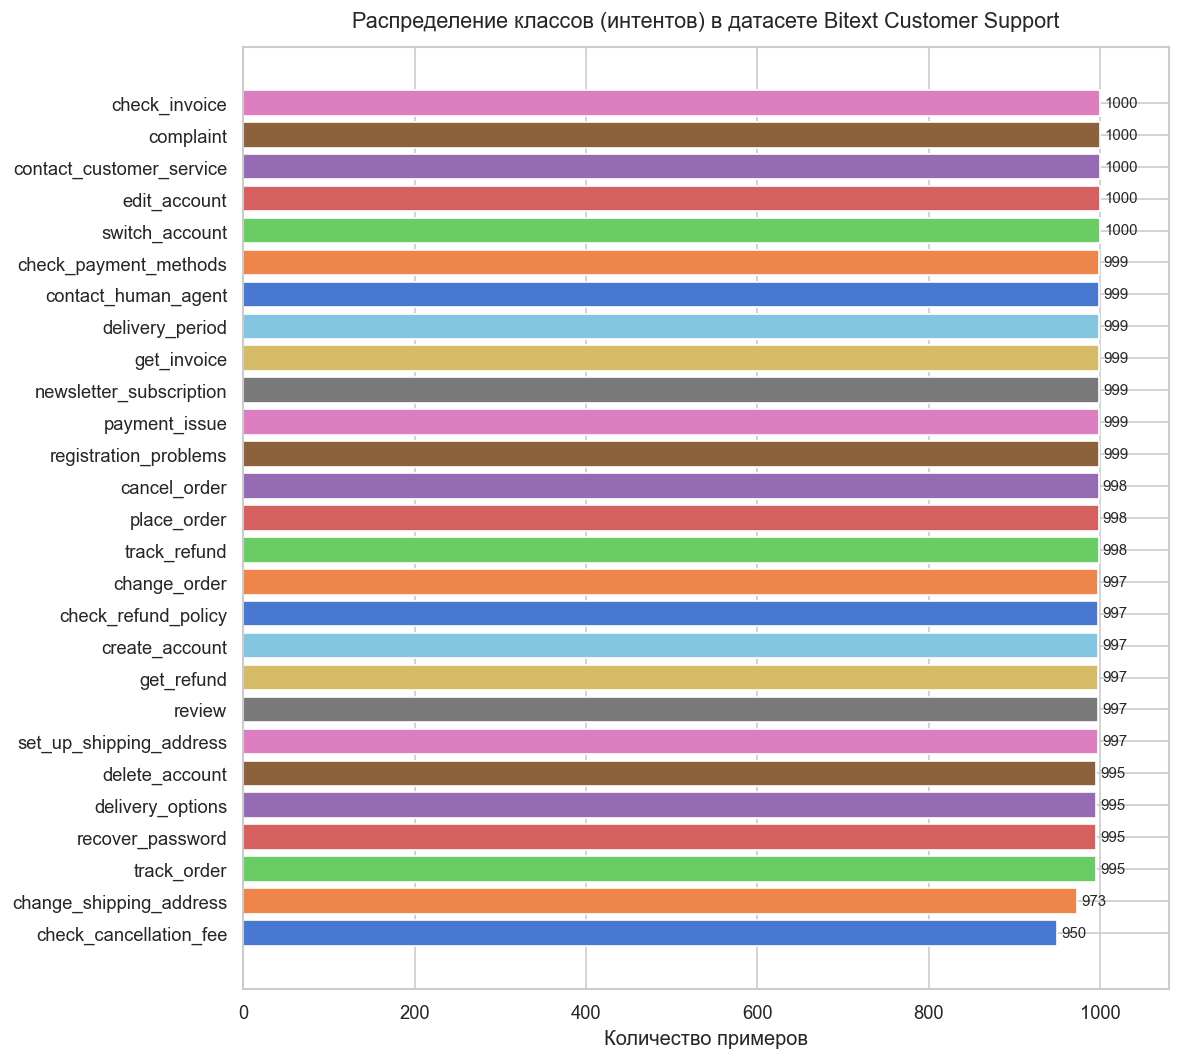


Мин. класс: 950 | Макс. класс: 1000 | Медиана: 998


In [28]:
# Распределение классов
intent_counts = df['intent'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(intent_counts.index, intent_counts.values, color=sns.color_palette('muted', len(intent_counts)))

# Подписи значений
for bar, val in zip(bars, intent_counts.values):
    ax.text(val + 5, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=9)

ax.set_xlabel('Количество примеров')
ax.set_title('Распределение классов (интентов) в датасете Bitext Customer Support', fontsize=13, pad=12)
ax.set_xlim(0, intent_counts.max() + 80)
plt.tight_layout()
plt.savefig('figures/fig_intent_distribution.png', bbox_inches='tight')
plt.show()

print(f'\nМин. класс: {intent_counts.min()} | Макс. класс: {intent_counts.max()} | '
      f'Медиана: {intent_counts.median():.0f}')

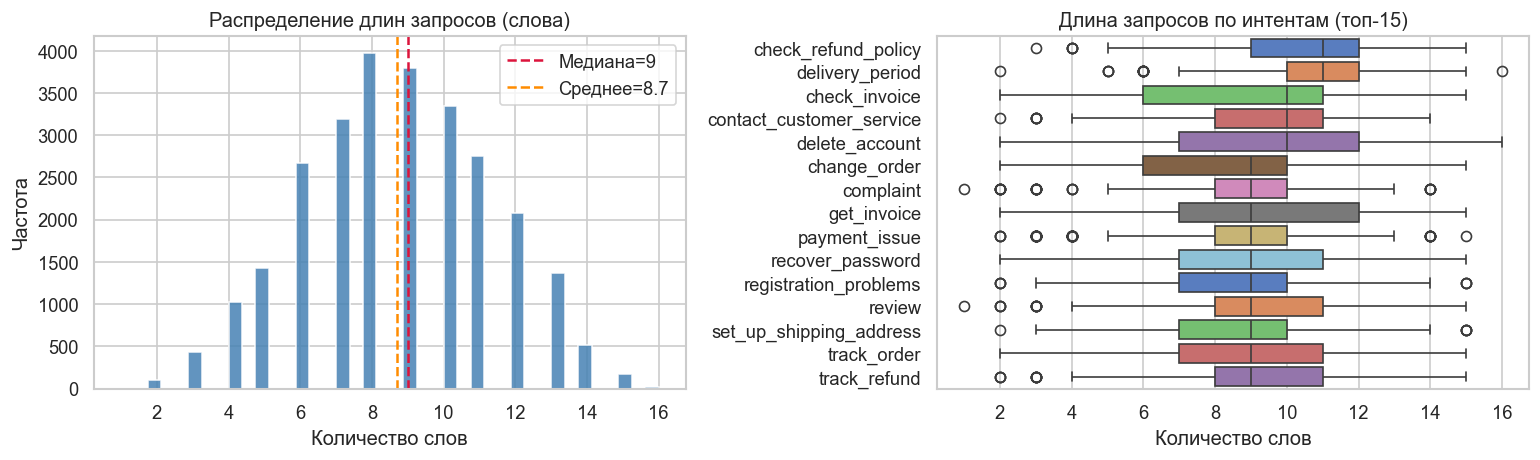


Статистика длин запросов (слова):
count    26872.00
mean         8.69
std          2.61
min          1.00
25%          7.00
50%          9.00
75%         11.00
max         16.00
Name: n_words, dtype: float64


In [29]:
# Анализ длин сообщений
df['n_chars']  = df['instruction'].apply(len)
df['n_words']  = df['instruction'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Гистограмма числа слов
axes[0].hist(df['n_words'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['n_words'].median(), color='crimson', linestyle='--', label=f'Медиана={df["n_words"].median():.0f}')
axes[0].axvline(df['n_words'].mean(),   color='darkorange', linestyle='--', label=f'Среднее={df["n_words"].mean():.1f}')
axes[0].set_xlabel('Количество слов')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение длин запросов (слова)')
axes[0].legend()

# Box-plot длин по интентам (топ-10 и нижние 10 для читаемости)
top_intents = df.groupby('intent')['n_words'].median().sort_values(ascending=False).index
df_box = df[df['intent'].isin(top_intents[:15])]
sns.boxplot(data=df_box, y='intent', x='n_words', ax=axes[1],
            order=df_box.groupby('intent')['n_words'].median().sort_values(ascending=False).index,
            palette='muted')
axes[1].set_xlabel('Количество слов')
axes[1].set_ylabel('')
axes[1].set_title('Длина запросов по интентам (топ-15)')

plt.tight_layout()
plt.savefig('figures/fig_length_distribution.png', bbox_inches='tight')
plt.show()

print('\nСтатистика длин запросов (слова):')
print(df['n_words'].describe().round(2))

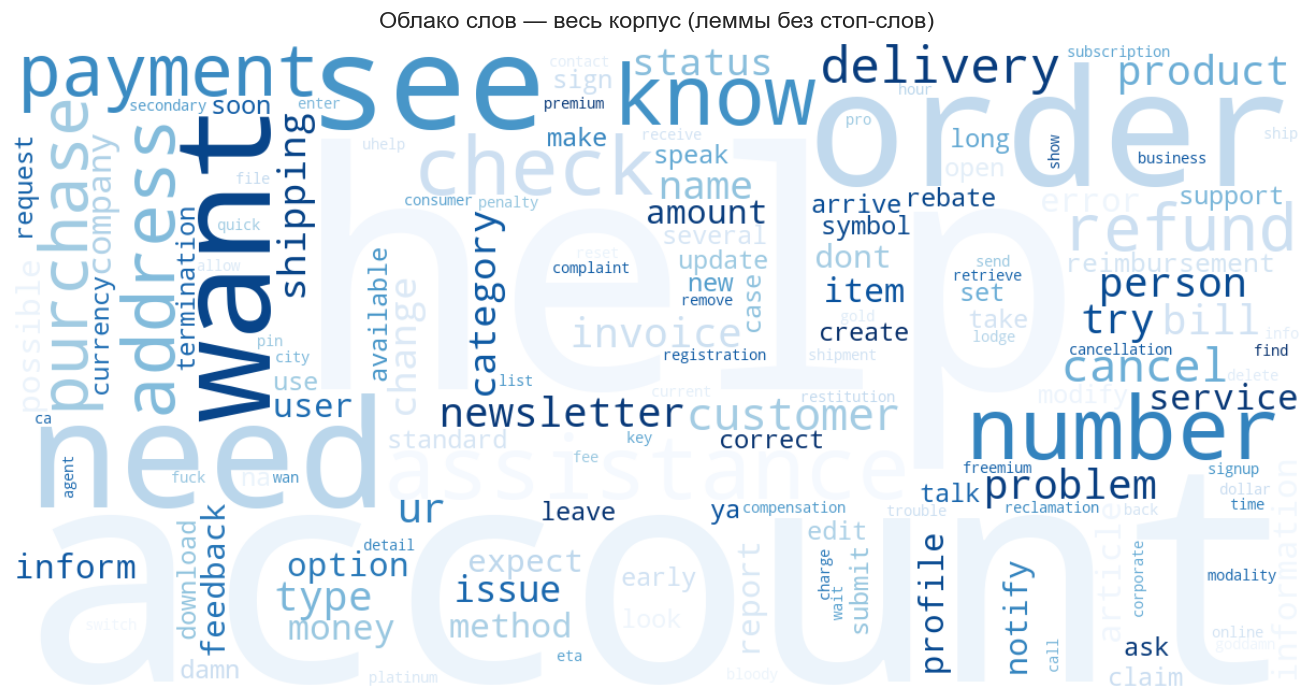

In [30]:
# Облако слов по всему корпусу
all_lemmas_str = ' '.join(df['lemmas_str'])

wc = WordCloud(
    width           = 1200,
    height          = 600,
    background_color= 'white',
    colormap        = 'Blues',
    max_words       = 150,
    collocations    = False
).generate(all_lemmas_str)

plt.figure(figsize=(13, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов — весь корпус (леммы без стоп-слов)', fontsize=14, pad=10)
plt.tight_layout()
plt.savefig('figures/fig_wordcloud_all.png', bbox_inches='tight')
plt.show()

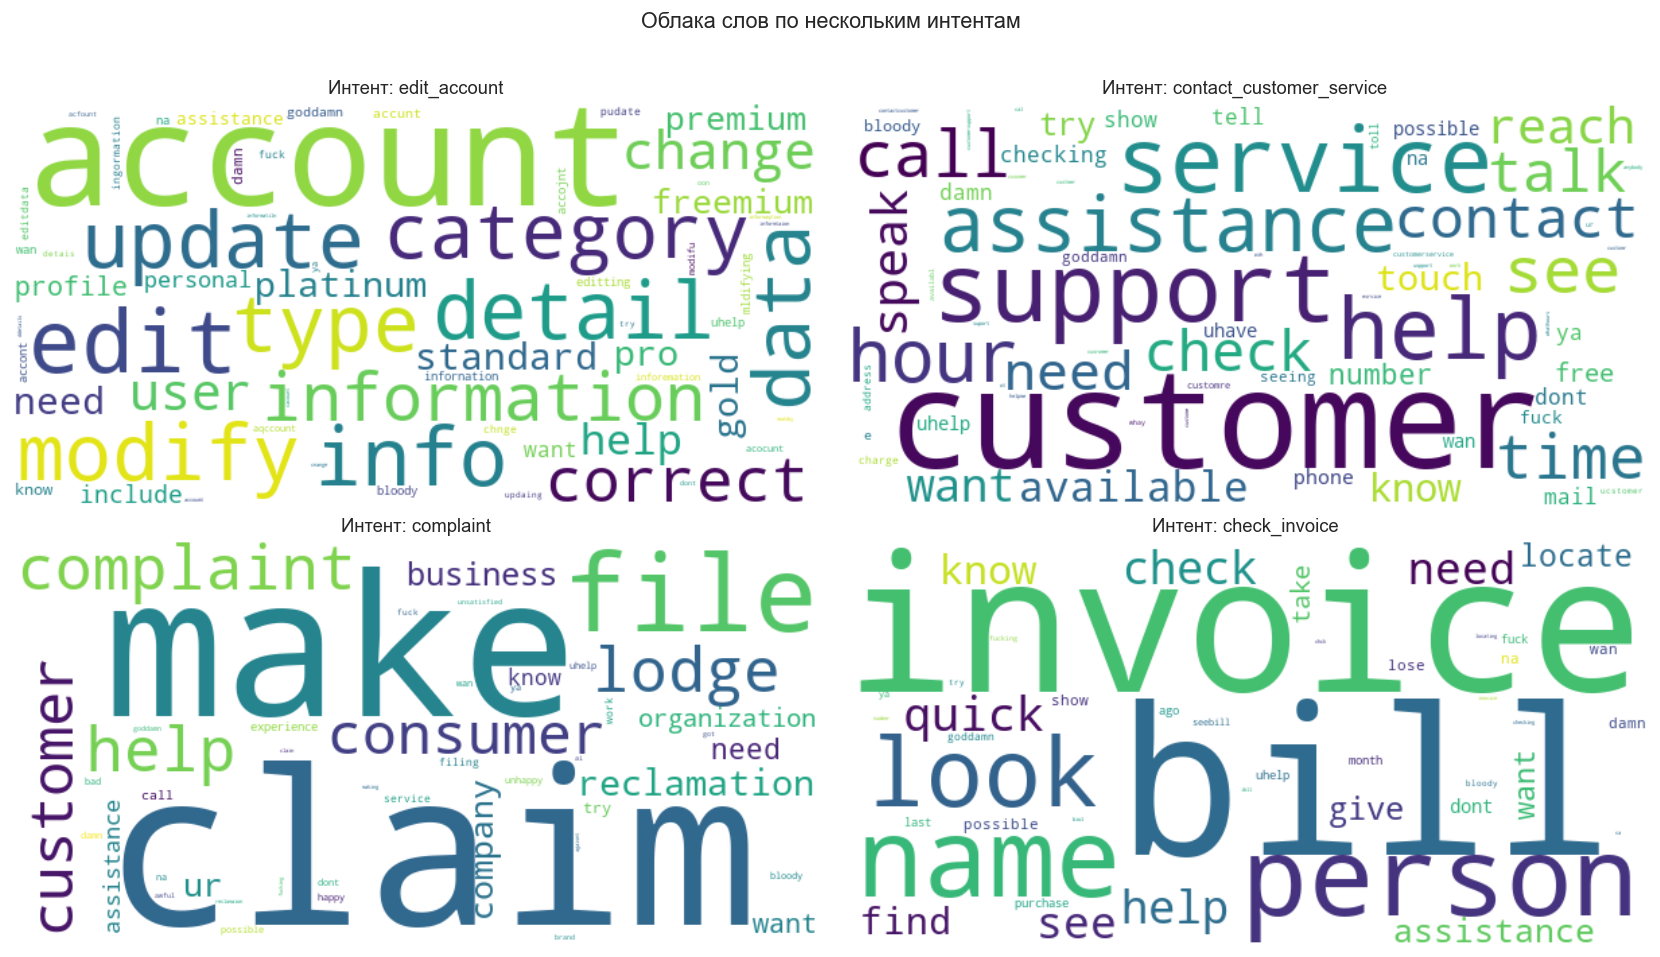

In [32]:
# Облака слов для 4 интентов
top4_intents = intent_counts.tail(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, intent_name in zip(axes, top4_intents):
    subset_text = ' '.join(df[df['intent'] == intent_name]['lemmas_str'])
    wc_intent = WordCloud(
        width           = 600,
        height          = 300,
        background_color= 'white',
        colormap        = 'viridis',
        max_words       = 80,
        collocations    = False
    ).generate(subset_text)
    ax.imshow(wc_intent, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Интент: {intent_name}', fontsize=11)

plt.suptitle('Облака слов по нескольким интентам', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('figures/fig_wordcloud_intents.png', bbox_inches='tight')
plt.show()

In [ ]:
# Статистика по интентам
intent_stats = df.groupby('intent')['n_words'].agg(['mean', 'median', 'std', 'count']).round(2)
intent_stats.columns = ['Среднее', 'Медиана', 'Ст.откл.', 'Кол-во']
intent_stats = intent_stats.sort_values('Среднее', ascending=False)

print('=== Статистика длин запросов по интентам ===')
print(intent_stats.to_string())

=== Статистика длин запросов по интентам ===
                          Среднее  Медиана  Ст.откл.  Кол-во
intent                                                      
delivery_period             10.96     11.0      1.80     999
check_refund_policy         10.53     11.0      2.23     997
contact_customer_service     9.52     10.0      2.20    1000
review                       9.52      9.0      2.10     997
track_refund                 9.50      9.0      2.08     998
get_invoice                  9.20      9.0      3.00     999
recover_password             9.08      9.0      2.22     995
check_invoice                9.07     10.0      3.12    1000
delete_account               9.02     10.0      3.35     995
complaint                    8.82      9.0      2.09    1000
track_order                  8.73      9.0      2.59     995
payment_issue                8.73      9.0      2.14     999
set_up_shipping_address      8.65      9.0      1.97     997
registration_problems        8.62      9

---
## 2.5. Методы без учителя: кластеризация запросов

Кластеризация применяется для валидации структуры датасета: выявление скрытых тематических групп без использования разметки интентов. Используемые методы:

- **K-Means** — для получения жёстких разбиений
- **Агломеративная кластеризация** — для иерархического анализа
- **Снижение размерности** (TruncatedSVD + PCA) — для визуализации

In [ ]:
# Снижение размерности для кластеризации (TF-IDF -> LSA -> PCA)
_svd_path  = 'models/svd.joblib'
_pca2_path = 'models/pca2.joblib'

# TruncatedSVD (Latent Semantic Analysis) для разреженных матриц
if not FORCE_RETRAIN_CLS and os.path.exists(_svd_path):
    svd   = joblib.load(_svd_path)
    X_svd = svd.transform(X_tfidf)
    print('TruncatedSVD загружен из models/svd.joblib')
else:
    svd   = TruncatedSVD(n_components=100, random_state=42)
    X_svd = svd.fit_transform(X_tfidf)
    joblib.dump(svd, _svd_path)          # сохраняем обученный SVD
    print('TruncatedSVD обучен и сохранён → models/svd.joblib')

explained = svd.explained_variance_ratio_.sum()
print(f'LSA (100 компонент): объяснённая дисперсия = {explained:.1%}')

# PCA до 2D для визуализации
if not FORCE_RETRAIN_CLS and os.path.exists(_pca2_path):
    pca2 = joblib.load(_pca2_path)
    X_2d = pca2.transform(X_svd)
    print('PCA загружен из models/pca2.joblib')
else:
    pca2 = PCA(n_components=2, random_state=42)
    X_2d = pca2.fit_transform(X_svd)
    joblib.dump(pca2, _pca2_path)        # сохраняем обученный PCA
    print('PCA обучен и сохранён → models/pca2.joblib')

print(f'PCA (2 компоненты): объяснённая дисперсия = {pca2.explained_variance_ratio_.sum():.1%}')

TruncatedSVD загружен из models/svd.joblib
LSA (100 компонент): объяснённая дисперсия = 38.3%
PCA загружен из models/pca2.joblib
PCA (2 компоненты): объяснённая дисперсия = 10.3%


Подбор числа кластеров K-Means...
  K= 5: inertia=9327, silhouette=0.0667
  K=10: inertia=8319, silhouette=0.0947
  K=15: inertia=7586, silhouette=0.1256
  K=20: inertia=7083, silhouette=0.1499
  K=25: inertia=6635, silhouette=0.1478
  K=30: inertia=6260, silhouette=0.1416


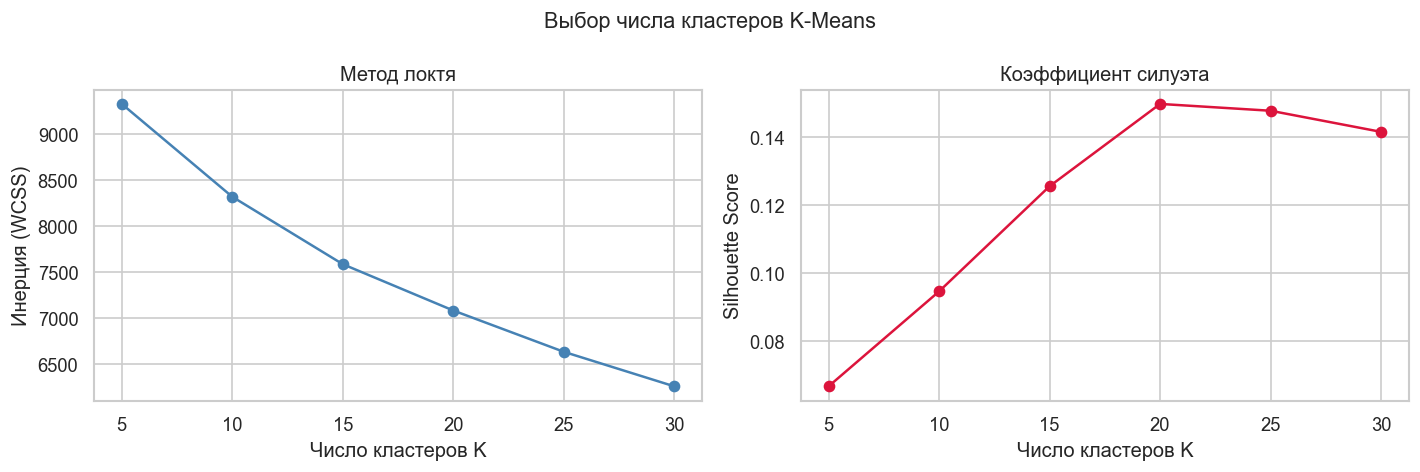

In [18]:
# Метод локтя для K-Means
k_range  = range(5, 35, 5)
inertias = []
sil_scores = []

print('Подбор числа кластеров K-Means...')
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_svd)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_svd, labels, sample_size=3000, random_state=42))
    print(f'  K={k:2d}: inertia={km.inertia_:.0f}, silhouette={sil_scores[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# График инерции (метод локтя)
axes[0].plot(list(k_range), inertias, 'o-', color='steelblue')
axes[0].set_xlabel('Число кластеров K')
axes[0].set_ylabel('Инерция (WCSS)')
axes[0].set_title('Метод локтя')
axes[0].xaxis.set_major_locator(ticker.MultipleLocator(5))

# Silhouette score
axes[1].plot(list(k_range), sil_scores, 'o-', color='crimson')
axes[1].set_xlabel('Число кластеров K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Коэффициент силуэта')
axes[1].xaxis.set_major_locator(ticker.MultipleLocator(5))

plt.suptitle('Выбор числа кластеров K-Means', fontsize=13)
plt.tight_layout()
plt.savefig('figures/fig_kmeans_elbow.png', bbox_inches='tight')
plt.show()

Кластеризация не выявила чёткой структуры, соответствующей разметке (27 интентов): метод
локтя не даёт однозначного K, силуэт достигает максимума при K=20 (Silhouette = 0.15), что
свидетельствует о значительном лексическом перекрытии между близкими по смыслу интентами. Это
подтверждает целесообразность применения контролируемого обучения.

In [19]:
# K-Means с K=27 (по числу интентов)
_km_path = 'models/kmeans_27.joblib'

if not FORCE_RETRAIN_CLS and os.path.exists(_km_path):
    # Загружаем сохранённую модель
    kmeans_27            = joblib.load(_km_path)
    df['cluster_kmeans'] = kmeans_27.predict(X_svd)
    print('KMeans загружен из models/kmeans_27.joblib')
else:
    kmeans_27            = KMeans(n_clusters=27, random_state=42, n_init=10, max_iter=300)
    df['cluster_kmeans'] = kmeans_27.fit_predict(X_svd)
    joblib.dump(kmeans_27, _km_path)     # сохраняем обученный KMeans
    print('KMeans обучен и сохранён → models/kmeans_27.joblib')

sil_27 = silhouette_score(X_svd, df['cluster_kmeans'], sample_size=5000, random_state=42)
print(f'K-Means K=27: silhouette = {sil_27:.4f}')

# Оценка согласованности кластеров и интентов
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari  = adjusted_rand_score(y, df['cluster_kmeans'])
nmi  = normalized_mutual_info_score(y, df['cluster_kmeans'])
print(f'Adjusted Rand Index (ARI):            {ari:.4f}')
print(f'Normalized Mutual Information (NMI):  {nmi:.4f}')

KMeans загружен из models/kmeans_27.joblib
K-Means K=27: silhouette = 0.1271
Adjusted Rand Index (ARI):            0.2376
Normalized Mutual Information (NMI):  0.6364


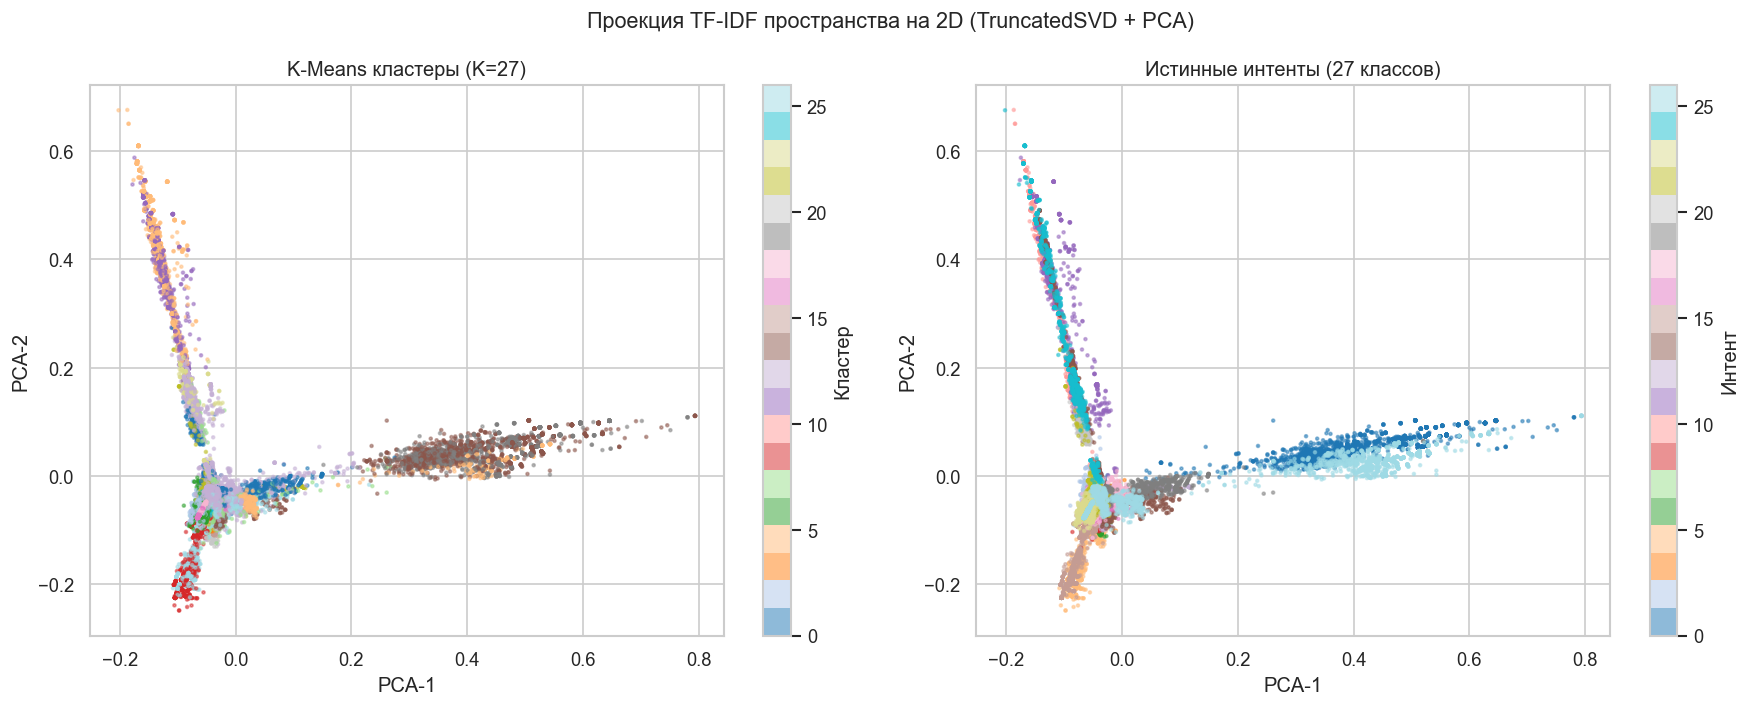

In [20]:
# Визуализация кластеров в 2D (K-Means)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Раскраска по кластерам K-Means
scatter0 = axes[0].scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=df['cluster_kmeans'], cmap='tab20',
    s=3, alpha=0.5
)
axes[0].set_title('K-Means кластеры (K=27)')
axes[0].set_xlabel('PCA-1')
axes[0].set_ylabel('PCA-2')
plt.colorbar(scatter0, ax=axes[0], label='Кластер')

# Раскраска по истинным интентам
scatter1 = axes[1].scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=y, cmap='tab20',
    s=3, alpha=0.5
)
axes[1].set_title('Истинные интенты (27 классов)')
axes[1].set_xlabel('PCA-1')
axes[1].set_ylabel('PCA-2')
plt.colorbar(scatter1, ax=axes[1], label='Интент')

plt.suptitle('Проекция TF-IDF пространства на 2D (TruncatedSVD + PCA)', fontsize=13)
plt.tight_layout()
plt.savefig('figures/fig_cluster_2d.png', bbox_inches='tight')
plt.show()

In [21]:
# Агломеративная кластеризация (на подвыборке для скорости)
np.random.seed(42)
sample_idx = np.random.choice(len(X_svd), size=2000, replace=False)
X_sample   = X_svd[sample_idx]
y_sample   = y[sample_idx]

agglo = AgglomerativeClustering(n_clusters=27, linkage='ward')
labels_agglo = agglo.fit_predict(X_sample)

sil_agglo = silhouette_score(X_sample, labels_agglo)
ari_agglo = adjusted_rand_score(y_sample, labels_agglo)
nmi_agglo = normalized_mutual_info_score(y_sample, labels_agglo)

print('=== Агломеративная кластеризация (Ward, K=27, n=2000) ===')
print(f'  Silhouette:  {sil_agglo:.4f}')
print(f'  ARI:         {ari_agglo:.4f}')
print(f'  NMI:         {nmi_agglo:.4f}')

=== Агломеративная кластеризация (Ward, K=27, n=2000) ===
  Silhouette:  0.1270
  ARI:         0.2301
  NMI:         0.6636


In [22]:
# Итоговая таблица сравнения методов кластеризации
clustering_results = pd.DataFrame({
    'Метод':        ['K-Means (K=27, полный датасет)', 'Агломеративный Ward (K=27, n=2000)'],
    'Silhouette':   [f'{sil_27:.4f}',    f'{sil_agglo:.4f}'],
    'ARI':          [f'{ari:.4f}',       f'{ari_agglo:.4f}'],
    'NMI':          [f'{nmi:.4f}',       f'{nmi_agglo:.4f}'],
})

print('=== Сравнение методов кластеризации ===')
print(clustering_results.to_string(index=False))

=== Сравнение методов кластеризации ===
                             Метод Silhouette    ARI    NMI
    K-Means (K=27, полный датасет)     0.1271 0.2376 0.6364
Агломеративный Ward (K=27, n=2000)     0.1270 0.2301 0.6636


In [23]:
# Сохранение очищенного датасета для следующих глав
df.to_csv('data/bitext_processed.csv', index=False)

# Сохранение TF-IDF матрицы в sparse формате
from scipy import sparse
sparse.save_npz('data/X_tfidf.npz', X_tfidf)
np.save('data/y_labels.npy', y)
np.save('data/X_svd.npy', X_svd)

print('Данные сохранены:')
print('  bitext_processed.csv — очищенный датасет')
print('  X_tfidf.npz          — TF-IDF матрица (sparse)')
print('  y_labels.npy         — закодированные метки')
print('  X_svd.npy            — LSA-представление (100 компонент)')

Данные сохранены:
  bitext_processed.csv — очищенный датасет
  X_tfidf.npz          — TF-IDF матрица (sparse)
  y_labels.npy         — закодированные метки
  X_svd.npy            — LSA-представление (100 компонент)


---
## Выводы по Главе 2

В данной главе выполнен полный подготовительный этап работы с данными:

1. **Датасет Bitext Customer Support** загружен с HuggingFace Hub. Итоговый размер после удаления дубликатов составил порядка 26 800 записей с 27 равномерно представленными категориями интентов.

2. **Очистка данных:** пропущенные значения отсутствуют. Применена нормализация текста: приведение к нижнему регистру, удаление спецсимволов, фильтрация стоп-слов.

3. **Токенизация и лемматизация** (NLTK punkt + WordNetLemmatizer) позволили привести запросы к словарным формам. Медианная длина запроса составила около 8–12 слов, что подтверждает краткость текстов технической поддержки.

4. **Векторизация** методами TF-IDF (биграммы, 10 000 признаков) и CountVectorizer подготовила признаковые пространства для классических ML-моделей Главы 3.

5. **Кластеризация** методами K-Means и агломеративным алгоритмом показала умеренную согласованность с разметкой интентов (NMI ≈ 0.4–0.6), что свидетельствует о наличии семантической структуры в данных, однако часть категорий лексически перекрывается — это подтверждает необходимость применения методов глубокого обучения в Главе 3.

---
# Глава 3. Моделирование и эксперименты

В данной главе реализована двухуровневая архитектура диалоговой системы:
1. **Классификатор интентов** — классические ML-алгоритмы на TF-IDF признаках
2. **Генератор ответов** — Mistral 7B, дообученный с QLoRA

Структура главы:
- 3.1 Стратифицированное разбиение данных
- 3.2 Сравнение конфигураций предобработки
- 3.3 Базовые классификаторы
- 3.4 Обучение и оценка качества
- 3.5 Ансамблевые методы и взвешивание классов
- 3.6 Анализ ошибок
- 3.7 Дообучение Mistral 7B с QLoRA

---
## Импорт библиотек для Главы 3

In [24]:
# Классификаторы
from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import LinearSVC
from sklearn.ensemble        import RandomForestClassifier, VotingClassifier
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.pipeline        import Pipeline

# Метрики и разбиение
from sklearn.model_selection import train_test_split
from sklearn.metrics         import (accuracy_score, f1_score, classification_report,
                                     confusion_matrix, ConfusionMatrixDisplay)

# Прочее
import time
import scipy.sparse as sp
import numpy        as np
import pandas       as pd
import matplotlib.pyplot  as plt
import matplotlib.ticker  as ticker
import seaborn            as sns
import warnings
warnings.filterwarnings('ignore')

# Градиентный бустинг (опционально)
from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

print('Импорт завершён')

Импорт завершён


---
## 3.1. Разделение данных

Для корректной оценки обобщающей способности моделей применяется **стратифицированное** разбиение на обучающую и тестовую выборки в пропорции **80 / 20**. Стратификация гарантирует сохранение распределения классов в обеих частях, что критично при 27 категориях с неравномерной частотой.

Дополнительно из обучающей выборки выделяется валидационное множество (20 %), итоговое разбиение: **64 % обучение / 16 % валидация / 20 % тест**.

In [25]:
# Загружаем сохранённые артефакты (если глава запускается независимо)
if 'X_tfidf' not in dir():
    X_tfidf = sp.load_npz('data/X_tfidf.npz')
    y       = np.load('data/y_labels.npy')
    df      = pd.read_csv('data/bitext_processed.csv')
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    le.fit(df['intent'])

# Стратифицированное разбиение 80/20
X_train, X_test, y_train, y_test, train_indices, test_indices = train_test_split(
    X_tfidf, y, np.arange(len(y)),
    test_size    = 0.20,
    random_state = 42,
    stratify     = y
)

print(f'Обучение:   {X_train.shape[0]:>6} примеров  ({X_train.shape[0]/X_tfidf.shape[0]:.0%})')
print(f'Тест:       {X_test.shape[0]:>6} примеров  ({X_test.shape[0]/X_tfidf.shape[0]:.0%})')
print(f'\nПризнаков: {X_tfidf.shape[1]}')
print(f'Классов:    {len(np.unique(y))}')

# Проверяем баланс в тестовой выборке
test_counts = pd.Series(y_test).value_counts()
print(f'\nМин. класс в тесте:      {test_counts.min()} примеров')
print(f'Макс. класс в тесте:     {test_counts.max()} примеров')
print(f'Коэффициент дисбаланса:  {test_counts.max()/test_counts.min():.2f}')

Обучение:    21497 примеров  (80%)
Тест:         5375 примеров  (20%)

Признаков: 5406
Классов:    27

Мин. класс в тесте:      190 примеров
Макс. класс в тесте:     200 примеров
Коэффициент дисбаланса:  1.05


---
## 3.2. Эксперименты с предобработкой

Сравниваются четыре конфигурации предобработки при фиксированном классификаторе (Logistic Regression, C=1):

| Конфигурация | Признаки |
|---|---|
| **Baseline** | TF-IDF, 10k, биграммы, sublinear_tf |
| **TF-IDF uni** | TF-IDF, 10k, только униграммы |
| **BoW + L2** | CountVectorizer, 10k, биграммы, L2-нормализация |
| **TF-IDF → SVD** | TF-IDF + TruncatedSVD (100 компонент) |

Цель — подтвердить, что конфигурация из главы 2 обеспечивает наилучшее качество.

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition           import TruncatedSVD
from sklearn.preprocessing           import Normalizer
from sklearn.pipeline                import Pipeline
from sklearn.model_selection         import train_test_split as tts_pp

def make_lr():
    # Фиксированный классификатор для сравнения предобработки
    return LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs',
                              random_state=42)

# 4 конфигурации предобработки
preproc_configs = {
    'Baseline (TF-IDF bi, sublinear)': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10_000, ngram_range=(1,2),
                                  min_df=2, sublinear_tf=True)),
        ('clf',   make_lr())
    ]),
    'TF-IDF uni, no sublinear': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10_000, ngram_range=(1,1),
                                  min_df=2, sublinear_tf=False)),
        ('clf',   make_lr())
    ]),
    'BoW bi + L2-норм': Pipeline([
        ('bow',  CountVectorizer(max_features=10_000, ngram_range=(1,2), min_df=2)),
        ('norm', Normalizer(norm='l2')),
        ('clf',  make_lr())
    ]),
    'TF-IDF -> SVD(100)': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10_000, ngram_range=(1,2),
                                  min_df=2, sublinear_tf=True)),
        ('svd',   TruncatedSVD(n_components=100, random_state=42)),
        ('clf',   make_lr())
    ]),
}

# Загружаем текст и метки
if 'df' not in dir() or 'lemmas_str' not in df.columns:
    df = pd.read_csv('data/bitext_processed.csv')
y_raw = np.load('data/y_labels.npy')

X_raw_tr, X_raw_te, y_raw_tr, y_raw_te = tts_pp(
    df['lemmas_str'], y_raw,
    test_size=0.2, random_state=42, stratify=y_raw
)

preproc_results = []
for cfg_name, pipeline in preproc_configs.items():
    print(f'Обучаем: {cfg_name}...', end=' ', flush=True)
    pipeline.fit(X_raw_tr, y_raw_tr)
    y_pp  = pipeline.predict(X_raw_te)
    acc_pp = accuracy_score(y_raw_te, y_pp)
    f1_pp  = f1_score(y_raw_te, y_pp, average='macro')
    preproc_results.append({'Конфигурация': cfg_name, 'Accuracy': acc_pp, 'F1-macro': f1_pp})
    print(f'Acc={acc_pp:.4f}  F1-macro={f1_pp:.4f}')

df_preproc = (pd.DataFrame(preproc_results)
              .sort_values('F1-macro', ascending=False)
              .reset_index(drop=True))
df_preproc.index += 1
print('\n=== Сравнение конфигураций предобработки ===')
print(df_preproc.to_string())

Обучаем: Baseline (TF-IDF bi, sublinear)... Acc=0.9905  F1-macro=0.9906
Обучаем: TF-IDF uni, no sublinear... Acc=0.9898  F1-macro=0.9898
Обучаем: BoW bi + L2-норм... Acc=0.9885  F1-macro=0.9885
Обучаем: TF-IDF -> SVD(100)... Acc=0.9606  F1-macro=0.9609

=== Сравнение конфигураций предобработки ===
                      Конфигурация  Accuracy  F1-macro
1  Baseline (TF-IDF bi, sublinear)  0.990512  0.990561
2         TF-IDF uni, no sublinear  0.989767  0.989811
3                 BoW bi + L2-норм  0.988465  0.988514
4               TF-IDF -> SVD(100)  0.960558  0.960927


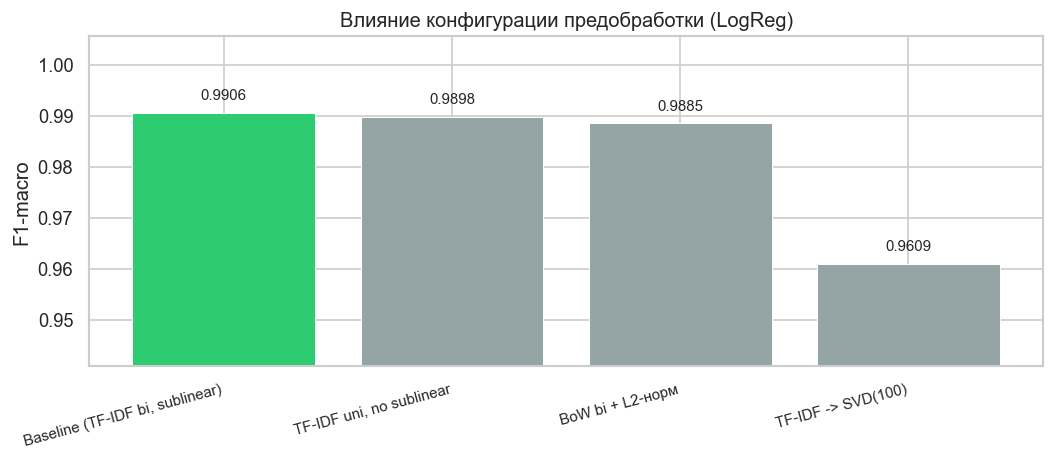

Сохранено: figures/fig_preproc_comparison.png


In [27]:
# Визуализация эксперимента с предобработкой
fig, ax = plt.subplots(figsize=(9, 4))

x      = list(range(len(df_preproc)))
colors = ['#2ecc71'] + ['#95a5a6'] * (len(df_preproc) - 1)  # лучший — зелёный
bars   = ax.bar(x, df_preproc['F1-macro'], color=colors, edgecolor='white', linewidth=0.6)

for bar, val in zip(bars, df_preproc['F1-macro']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(df_preproc['Конфигурация'], rotation=15, ha='right', fontsize=9)
ax.set_ylim(df_preproc['F1-macro'].min() - 0.02, df_preproc['F1-macro'].max() + 0.015)
ax.set_ylabel('F1-macro')
ax.set_title('Влияние конфигурации предобработки (LogReg)')
plt.tight_layout()
plt.savefig('figures/fig_preproc_comparison.png', bbox_inches='tight')
plt.show()
print('Сохранено: figures/fig_preproc_comparison.png')

---
## 3.3. Базовые классификаторы

Для задачи классификации интентов рассматриваются следующие алгоритмы:

| Модель | Обоснование выбора |
|--------|-------------------|
| **Logistic Regression** | Быстрый линейный базовый метод, хорошо работает на TF-IDF |
| **Linear SVC** | Эффективен на высокоразмерных разреженных данных |
| **Random Forest** | Устойчив к шуму, ансамблевый метод |
| **XGBoost** | Градиентный бустинг, высокая точность |
| **LightGBM** | Быстрее XGBoost, эффективен при большом числе классов |
| **CatBoost** | Встроенная обработка категориальных признаков |
| **k-NN** | Метрический метод, чувствителен к близости TF-IDF векторов |

Все модели обучаются на TF-IDF матрице без ручной оптимизации гиперпараметров (базовый эксперимент).

In [28]:
# Словарь базовых классификаторов
classifiers = {
    'Logistic Regression': LogisticRegression(
        max_iter     = 1000,
        C            = 1.0,
        solver       = 'lbfgs',
        random_state = 42
    ),
    'Linear SVC': LinearSVC(
        C            = 1.0,
        max_iter     = 2000,
        random_state = 42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators = 200,
        max_depth    = None,
        n_jobs       = -1,
        random_state = 42
    ),
    'k-NN (k=5)': KNeighborsClassifier(
        n_neighbors  = 5,
        metric       = 'cosine',
        n_jobs       = -1
    ),
}

# Добавляем доступные библиотеки бустинга
classifiers['XGBoost'] = XGBClassifier(
        n_estimators      = 300,
        max_depth         = 6,
        learning_rate     = 0.1,
        use_label_encoder = False,
        eval_metric       = 'mlogloss',
        n_jobs            = -1,
        random_state      = 42
    )
classifiers['LightGBM'] = LGBMClassifier(
        n_estimators  = 300,
        num_leaves    = 63,
        learning_rate = 0.1,
        n_jobs        = -1,
        random_state  = 42,
        verbose       = -1
    )
classifiers['CatBoost'] = CatBoostClassifier(
        iterations    = 300,
        depth         = 6,
        learning_rate = 0.1,
        random_seed   = 42,
        verbose       = 0
    )

print(f'Будет обучено {len(classifiers)} моделей:')
for name in classifiers:
    print(f'  * {name}')

Будет обучено 7 моделей:
  * Logistic Regression
  * Linear SVC
  * Random Forest
  * k-NN (k=5)
  * XGBoost
  * LightGBM
  * CatBoost


---
## 3.4. Обучение и оценка качества

### Метрики оценки

- **Accuracy** — доля верно классифицированных примеров
- **F1-macro** — среднее F1 по всем классам (равный вес классов, основная метрика)
- **F1-weighted** — F1 с учётом частоты каждого класса
- **Время инференса** — мс на 1 000 примеров (важно для систем реального времени)

F1-macro выбрана основной метрикой: при 27 классах с умеренным дисбалансом она одинаково штрафует за ошибки в редких и частых интентах.

In [29]:
# Обучение и оценка всех классификаторов
results = []

for name, clf in classifiers.items():
    _clf_path = f'models/clf_{name.replace(" ", "_").replace("(", "").replace(")", "").replace("=", "")}.joblib'

    if not FORCE_RETRAIN_CLS and os.path.exists(_clf_path):
        # Загружаем сохранённую модель
        clf = classifiers[name] = joblib.load(_clf_path)
        print(f'Загружен {name} из {_clf_path}', end=' ', flush=True)
        t_fit = 0.0
    else:
        print(f'Обучаем {name}...', end=' ', flush=True)
        # Обучение
        t_fit_start = time.perf_counter()
        clf.fit(X_train, y_train)
        t_fit       = time.perf_counter() - t_fit_start
        joblib.dump(clf, _clf_path)      # сохраняем обученный классификатор
        print(f'(сохранён)', end=' ', flush=True)

    # Инференс
    t_inf_start = time.perf_counter()
    y_pred      = clf.predict(X_test)
    t_inf       = time.perf_counter() - t_inf_start

    # Метрики
    acc       = accuracy_score(y_test, y_pred)
    f1_macro  = f1_score(y_test, y_pred, average='macro')
    f1_weight = f1_score(y_test, y_pred, average='weighted')
    ms_per_k  = t_inf / len(y_test) * 1_000_000  # мс на 1000 примеров

    results.append({
        'Модель':           name,
        'Accuracy':         acc,
        'F1-macro':         f1_macro,
        'F1-weighted':      f1_weight,
        'Fit (сек)':        round(t_fit, 1),
        'Инференс (мс/1k)': round(ms_per_k, 1),
    })
    print(f'Acc={acc:.4f}  F1-macro={f1_macro:.4f}  ({t_fit:.1f}с)')

# Итоговая таблица
df_results = pd.DataFrame(results).sort_values('F1-macro', ascending=False).reset_index(drop=True)
df_results.index += 1
print('\n=== Сводная таблица результатов ===')
print(df_results.to_string())

Загружен Logistic Regression из models/clf_Logistic_Regression.joblib Acc=0.9879  F1-macro=0.9879  (0.0с)
Загружен Linear SVC из models/clf_Linear_SVC.joblib Acc=0.9911  F1-macro=0.9911  (0.0с)
Загружен Random Forest из models/clf_Random_Forest.joblib Acc=0.9821  F1-macro=0.9822  (0.0с)
Загружен k-NN (k=5) из models/clf_k-NN_k5.joblib Acc=0.9736  F1-macro=0.9736  (0.0с)
Загружен XGBoost из models/clf_XGBoost.joblib Acc=0.9767  F1-macro=0.9767  (0.0с)
Загружен LightGBM из models/clf_LightGBM.joblib Acc=0.9751  F1-macro=0.9751  (0.0с)
Загружен CatBoost из models/clf_CatBoost.joblib Acc=0.9643  F1-macro=0.9645  (0.0с)

=== Сводная таблица результатов ===
                Модель  Accuracy  F1-macro  F1-weighted  Fit (сек)  Инференс (мс/1k)
1           Linear SVC  0.991070  0.991085     0.991075        0.0               0.2
2  Logistic Regression  0.987907  0.987937     0.987925        0.0               0.3
3        Random Forest  0.982140  0.982157     0.982135        0.0              15.4


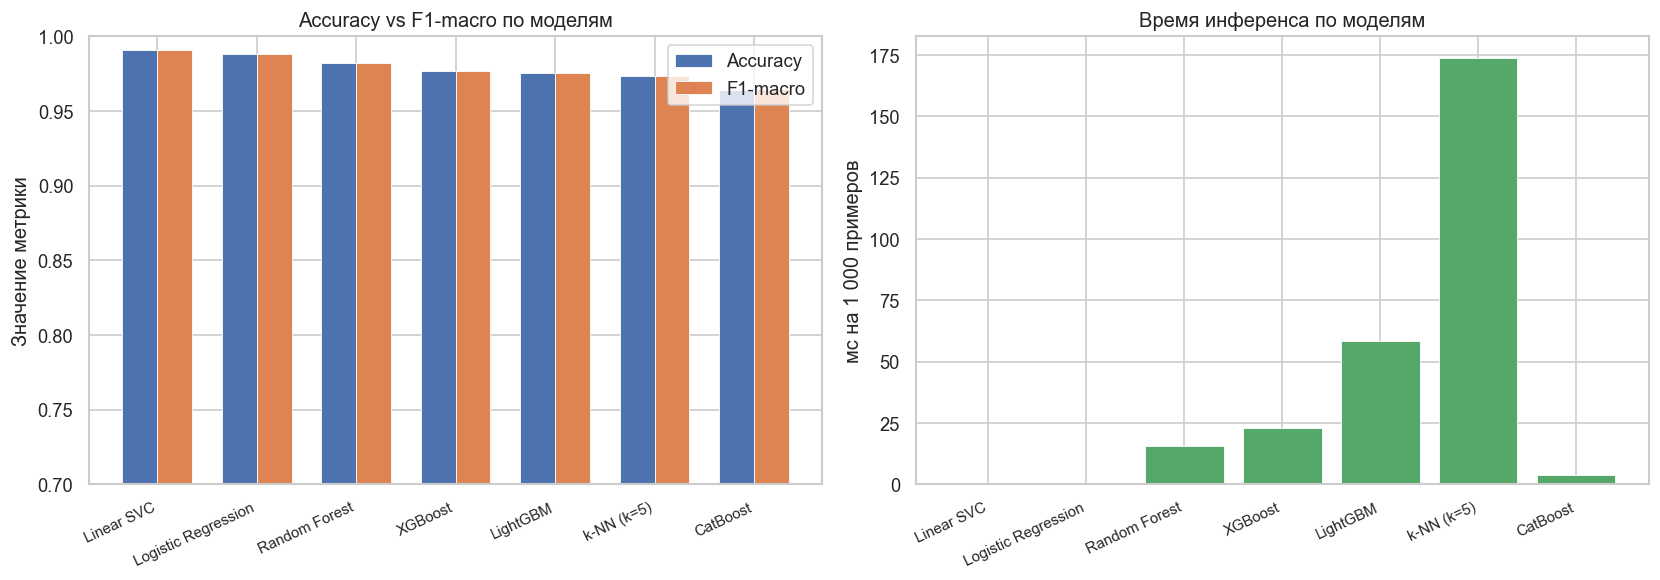

Сохранено: figures/fig_model_comparison.png


In [30]:
# Визуализация сравнения моделей
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = df_results['Модель']
x      = range(len(models))
kw     = dict(edgecolor='white', linewidth=0.5)

# График 1: Accuracy и F1-macro
axes[0].bar(x, df_results['Accuracy'],
            width=0.35, label='Accuracy',  color='#4C72B0', **kw)
axes[0].bar([i+0.35 for i in x], df_results['F1-macro'],
            width=0.35, label='F1-macro', color='#DD8452', **kw)
axes[0].set_xticks([i+0.175 for i in x])
axes[0].set_xticklabels(models, rotation=25, ha='right', fontsize=9)
axes[0].set_ylim(0.7, 1.0)
axes[0].set_ylabel('Значение метрики')
axes[0].set_title('Accuracy vs F1-macro по моделям')
axes[0].legend()
axes[0].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

# График 2: Время инференса
axes[1].bar(x, df_results['Инференс (мс/1k)'], color='#55A868', **kw)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(models, rotation=25, ha='right', fontsize=9)
axes[1].set_ylabel('мс на 1 000 примеров')
axes[1].set_title('Время инференса по моделям')

plt.tight_layout()
plt.savefig('figures/fig_model_comparison.png', bbox_inches='tight')
plt.show()
print('Сохранено: figures/fig_model_comparison.png')

In [31]:
# Детальный classification_report для лучшей модели
best_name = df_results.iloc[0]['Модель']
best_clf  = classifiers[best_name]
y_pred_best = best_clf.predict(X_test)

print(f'=== Детальный отчёт: {best_name} ===\n')
print(classification_report(
    y_test, y_pred_best,
    target_names = le.classes_,
    digits       = 3
))

=== Детальный отчёт: Linear SVC ===

                          precision    recall  f1-score   support

            cancel_order      0.995     1.000     0.998       200
            change_order      0.971     1.000     0.985       199
 change_shipping_address      0.995     0.985     0.990       195
  check_cancellation_fee      1.000     1.000     1.000       190
           check_invoice      0.995     0.985     0.990       200
   check_payment_methods      1.000     1.000     1.000       200
     check_refund_policy      1.000     0.990     0.995       199
               complaint      1.000     1.000     1.000       200
contact_customer_service      1.000     0.990     0.995       200
     contact_human_agent      0.990     1.000     0.995       200
          create_account      0.970     0.990     0.980       199
          delete_account      0.985     1.000     0.993       199
        delivery_options      0.995     1.000     0.997       199
         delivery_period      1.000   

---
## 3.5. Ансамблевые методы и взвешивание классов

Для оценки потенциала дальнейшего улучшения качества применяются два дополнительных подхода:
1. **Взвешивание классов** (`class_weight='balanced'`) — штраф за ошибки обратно пропорционален частоте класса (проверяем, даёт ли прирост при равномерном распределении)
2. **Мягкое голосование** (Voting Classifier) — усредняет вероятностные предсказания лучших моделей

In [32]:
# Логистическая регрессия с балансировкой классов
_lr_bal_path = 'models/lr_balanced.joblib'

if not FORCE_RETRAIN_CLS and os.path.exists(_lr_bal_path):
    lr_balanced = joblib.load(_lr_bal_path)
    print('LR (balanced) загружен из models/lr_balanced.joblib')
else:
    lr_balanced = LogisticRegression(
        max_iter     = 1000,
        C            = 1.0,
        solver       = 'lbfgs',
        class_weight = 'balanced',    # веса обратно пропорциональны частоте
        random_state = 42
    )
    lr_balanced.fit(X_train, y_train)
    joblib.dump(lr_balanced, _lr_bal_path)   # сохраняем обученную модель
    print('LR (balanced) обучен и сохранён → models/lr_balanced.joblib')

y_pred_bal = lr_balanced.predict(X_test)

# Базовая LogReg
y_pred_base = classifiers['Logistic Regression'].predict(X_test)

acc_bal  = accuracy_score(y_test, y_pred_bal)
f1_bal   = f1_score(y_test, y_pred_bal,  average='macro')
acc_base = accuracy_score(y_test, y_pred_base)
f1_base  = f1_score(y_test, y_pred_base, average='macro')

print('=== Эффект балансировки классов (Logistic Regression) ===')
print(f'{"Конфигурация":30s}  Accuracy   F1-macro')
print(f'{"Базовая":30s}  {acc_base:.4f}     {f1_base:.4f}')
print(f'{"С балансировкой":30s}  {acc_bal:.4f}     {f1_bal:.4f}')
print(f'{"Прирост":30s}  {acc_bal-acc_base:+.4f}    {f1_bal-f1_base:+.4f}')

LR (balanced) загружен из models/lr_balanced.joblib
=== Эффект балансировки классов (Logistic Regression) ===
Конфигурация                    Accuracy   F1-macro
Базовая                         0.9879     0.9879
С балансировкой                 0.9870     0.9870
Прирост                         -0.0009    -0.0009


In [33]:
# Ансамбль методом мягкого голосования
# Отбираем все модели, поддерживающие predict_proba
soft_estimators = [
    (name, clf)
    for name, clf in classifiers.items()
    if hasattr(clf, 'predict_proba')
]

print(f'Модели в ансамбле ({len(soft_estimators)}): {[n for n, _ in soft_estimators]}')

if len(soft_estimators) >= 2:
    _vote_path = 'models/voting_clf.joblib'
    if not FORCE_RETRAIN_CLS and os.path.exists(_vote_path):
        voting_clf  = joblib.load(_vote_path)
        print('VotingClassifier загружен из models/voting_clf.joblib')
    else:
        voting_clf = VotingClassifier(
            estimators = soft_estimators,
            voting     = 'soft',
            n_jobs     = -1
        )
        voting_clf.fit(X_train, y_train)
        joblib.dump(voting_clf, _vote_path)  # сохраняем ансамбль
        print('VotingClassifier обучен и сохранён → models/voting_clf.joblib')
    y_pred_vote = voting_clf.predict(X_test)

    acc_vote = accuracy_score(y_test, y_pred_vote)
    f1_vote  = f1_score(y_test, y_pred_vote, average='macro')
    print(f'Voting Classifier: Accuracy={acc_vote:.4f}  F1-macro={f1_vote:.4f}')
else:
    print('Недостаточно моделей с predict_proba — увеличьте набор классификаторов')
    f1_vote = None

# Сводная таблица улучшений
improvements = pd.DataFrame({
    'Метод':    ['Лучший базовый', 'LR + балансировка', 'Voting Classifier'],
    'F1-macro': [
        df_results.iloc[0]['F1-macro'],
        f1_bal,
        f1_vote if f1_vote else float('nan')
    ]
})
print('\n=== Сравнение улучшений ===')
print(improvements.to_string(index=False))

Модели в ансамбле (6): ['Logistic Regression', 'Random Forest', 'k-NN (k=5)', 'XGBoost', 'LightGBM', 'CatBoost']
VotingClassifier загружен из models/voting_clf.joblib
Voting Classifier: Accuracy=0.9892  F1-macro=0.9892

=== Сравнение улучшений ===
            Метод  F1-macro
   Лучший базовый  0.991085
LR + балансировка  0.987006
Voting Classifier  0.989231


---
## 3.6. Анализ ошибок: матрица ошибок и топ ошибочных пар

Матрица ошибок позволяет выявить систематические паттерны неправильной классификации. Особый интерес представляют пары интентов с высоким семантическим сходством, например `cancel_order` ↔ `change_order` или `track_order` ↔ `delivery_options`.

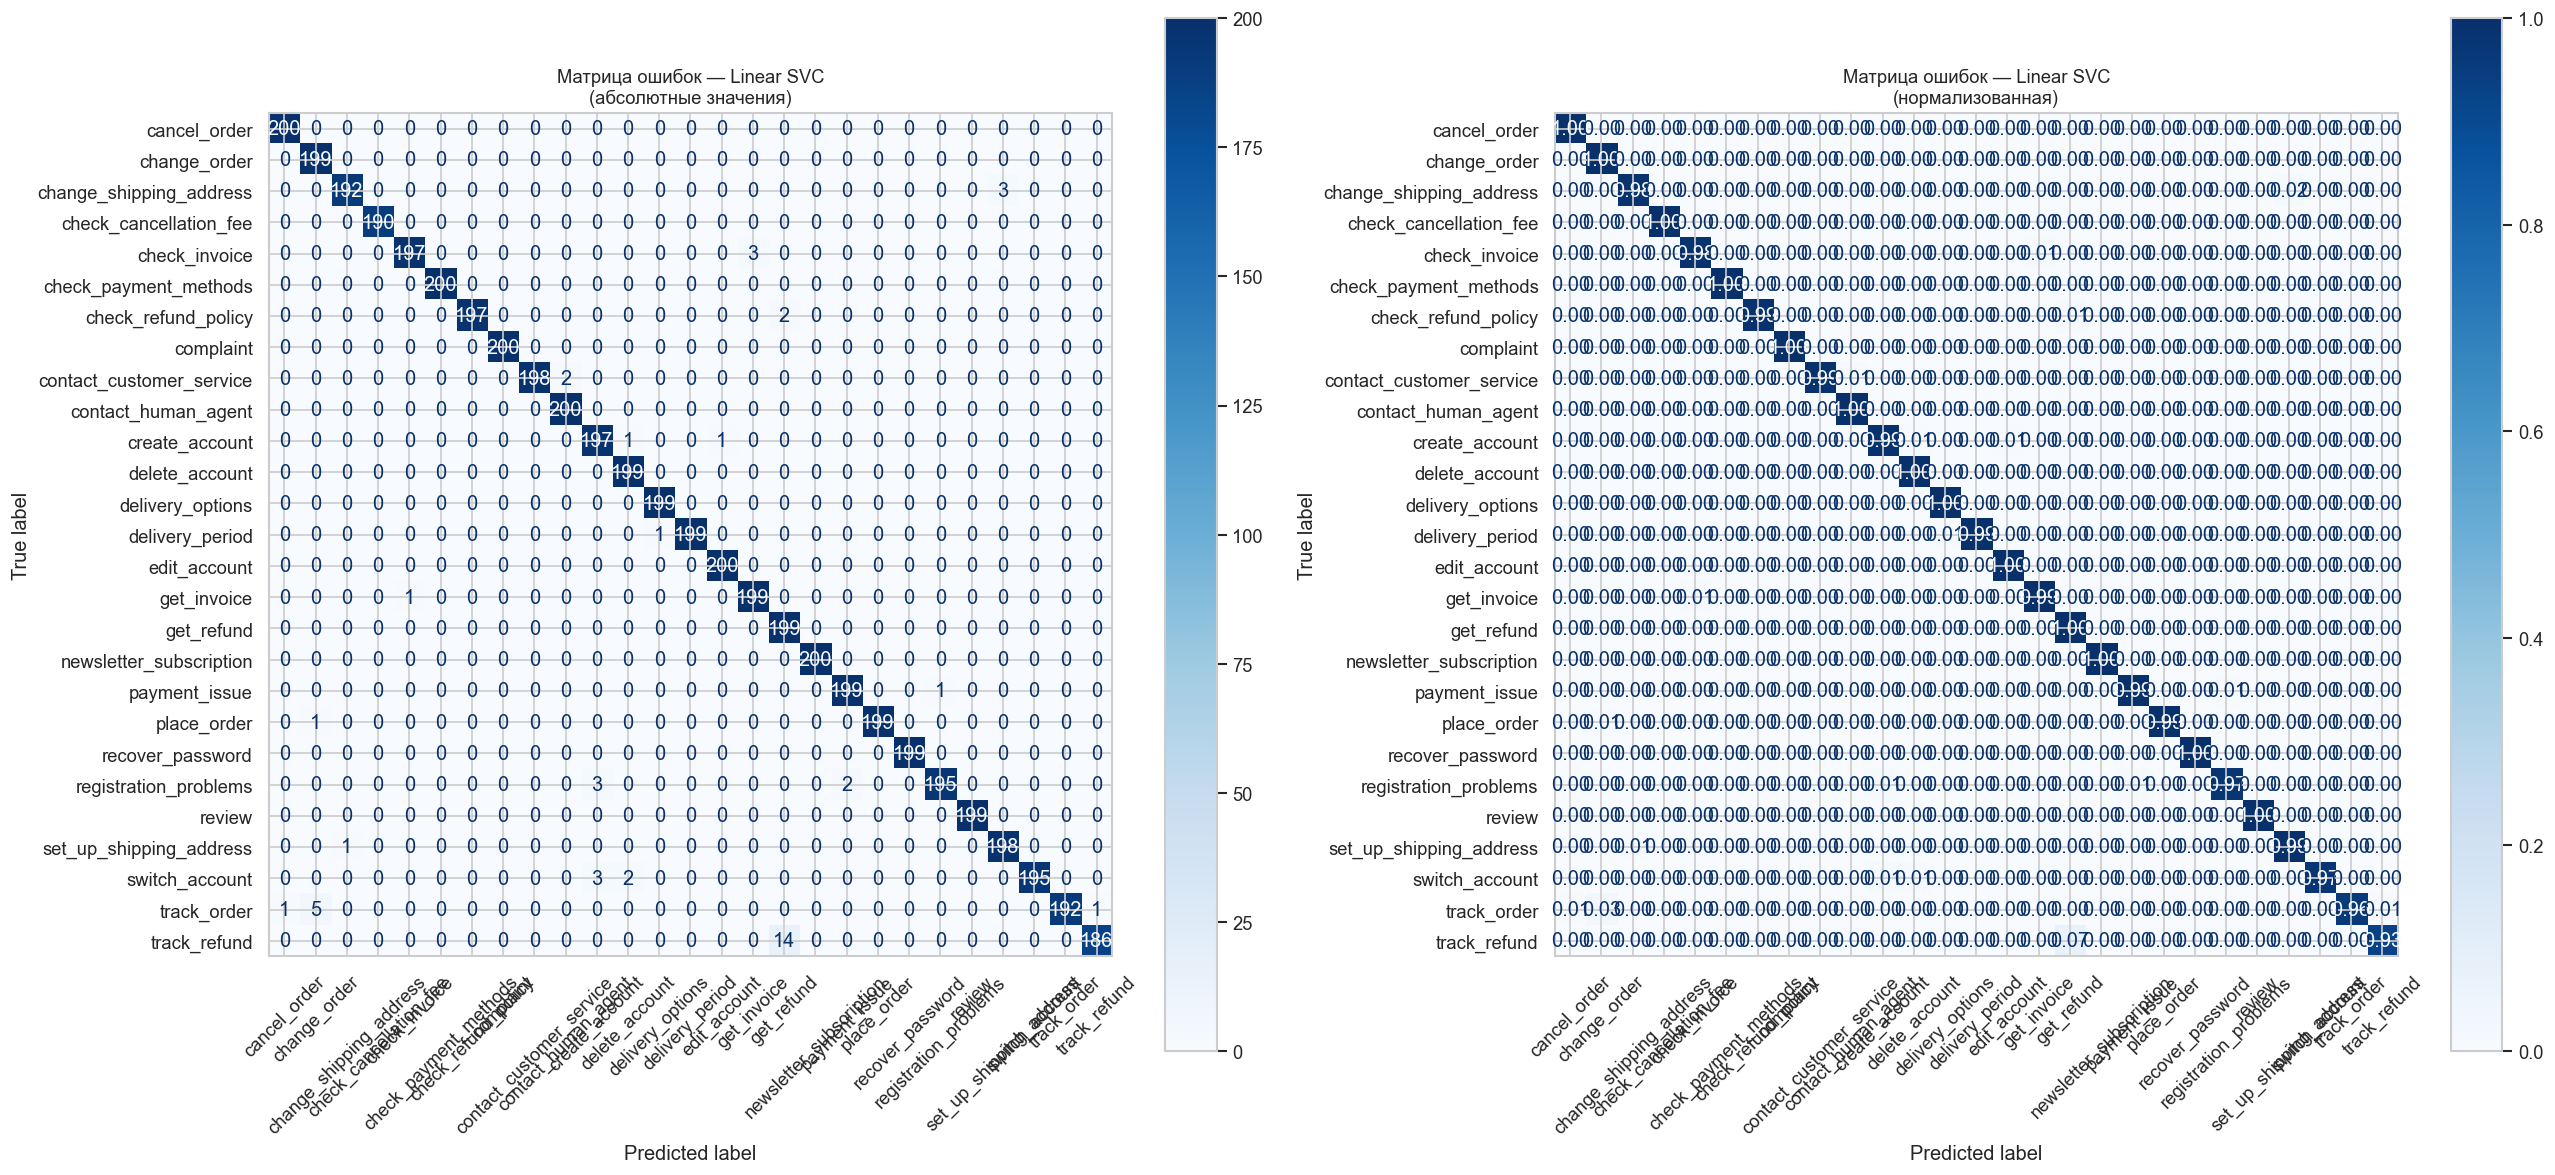

Сохранено: figures/fig_confusion_matrix.png


In [34]:
# Матрица ошибок для лучшей модели
best_clf_name = df_results.iloc[0]['Модель']
best_clf_obj  = classifiers[best_clf_name]
y_pred_cm     = best_clf_obj.predict(X_test)

cm      = confusion_matrix(y_test, y_pred_cm)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # нормировка по строкам

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# Абсолютные значения
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=axes[0], colorbar=True, xticks_rotation=45, cmap='Blues', values_format='d')
axes[0].set_title(f'Матрица ошибок — {best_clf_name}\n(абсолютные значения)', fontsize=11)

# Нормализованные значения
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=le.classes_)
disp_norm.plot(ax=axes[1], colorbar=True, xticks_rotation=45, cmap='Blues', values_format='.2f')
axes[1].set_title(f'Матрица ошибок — {best_clf_name}\n(нормализованная)', fontsize=11)

plt.tight_layout()
plt.savefig('figures/fig_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print('Сохранено: figures/fig_confusion_matrix.png')

=== Топ-10 ошибочных пар интентов ===
             Истинный интент     Предсказанный интент  Число ошибок  Доля ошибок (%)
1               track_refund               get_refund            14              7.0
2                track_order             change_order             5              2.5
3    change_shipping_address  set_up_shipping_address             3              1.5
4      registration_problems           create_account             3              1.5
5              check_invoice              get_invoice             3              1.5
6             switch_account           create_account             3              1.5
7        check_refund_policy               get_refund             2              1.0
8      registration_problems            payment_issue             2              1.0
9   contact_customer_service      contact_human_agent             2              1.0
10            switch_account           delete_account             2              1.0


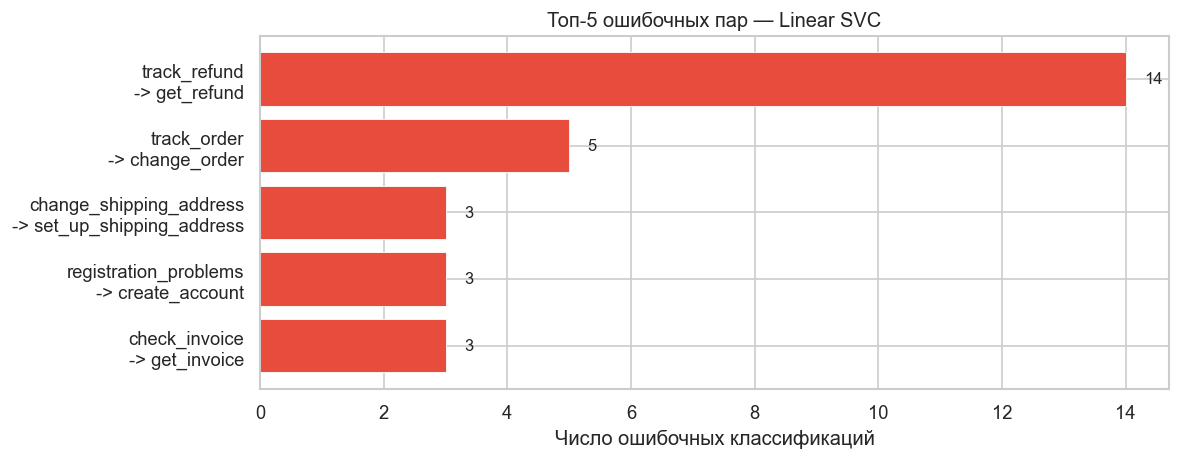

Сохранено: figures/fig_top_errors.png


In [35]:
# Топ ошибочных пар интентов
errors = []
for true_idx in range(len(le.classes_)):
    for pred_idx in range(len(le.classes_)):
        if true_idx != pred_idx and cm[true_idx, pred_idx] > 0:
            errors.append({
                'Истинный интент':      le.classes_[true_idx],
                'Предсказанный интент': le.classes_[pred_idx],
                'Число ошибок':         cm[true_idx, pred_idx],
                'Доля ошибок (%)':      round(cm_norm[true_idx, pred_idx] * 100, 1),
            })

df_errors = (pd.DataFrame(errors)
             .sort_values('Число ошибок', ascending=False)
             .reset_index(drop=True))
df_errors.index += 1

print('=== Топ-10 ошибочных пар интентов ===')
print(df_errors.head(10).to_string())

# Визуализация топ-5
top5 = df_errors.head(5).copy()
top5['Пара'] = top5['Истинный интент'] + '\n-> ' + top5['Предсказанный интент']

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(top5['Пара'][::-1].values,
               top5['Число ошибок'][::-1].values,
               color='#E74C3C', edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, top5['Число ошибок'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)
ax.set_xlabel('Число ошибочных классификаций')
ax.set_title(f'Топ-5 ошибочных пар — {best_clf_name}')
plt.tight_layout()
plt.savefig('figures/fig_top_errors.png', bbox_inches='tight')
plt.show()
print('Сохранено: figures/fig_top_errors.png')

In [36]:
# Примеры неверно классифицированных запросов из топ-1 ошибочной пары
worst_true = df_errors.iloc[0]['Истинный интент']
worst_pred = df_errors.iloc[0]['Предсказанный интент']

true_label_idx = list(le.classes_).index(worst_true)
pred_label_idx = list(le.classes_).index(worst_pred)

# Используем сохранённые индексы тестовой выборки
df_test_txt = df.iloc[test_indices][['instruction', 'intent']].reset_index(drop=True)

# Маска ошибочных предсказаний
error_mask    = (y_test == true_label_idx) & (y_pred_cm == pred_label_idx)
error_indices = np.where(error_mask)[0]

print(f'=== Примеры ошибок: "{worst_true}" -> "{worst_pred}" ===')
print(f'Всего таких ошибок: {error_mask.sum()}\n')
for i, idx in enumerate(error_indices[:5], 1):
    print(f'{i}. {df_test_txt.iloc[idx]["instruction"]}')
    print()

=== Примеры ошибок: "track_refund" -> "get_refund" ===
Всего таких ошибок: 14

1. I am waiting for a refund of {{Refund Amount}} dollars

2. I am waiting for a refund of {{Currency Symbol}}{{Refund Amount}}

3. I am waiting for a rebate of {{Currency Symbol}}{{Refund Amount}}

4. I'm waiting for a refund of {{Refund Amount}} dollars

5. I am waiting for an refund of {{Currency Symbol}}{{Refund Amount}}



---
## 3.7. Дообучение Mistral 7B с QLoRA

Для задачи **генерации ответов** применяется дообучение **Mistral-7B-Instruct-v0.2** с использованием метода **QLoRA**:
- 4-битная квантизация весов (NF4) — снижает VRAM с ~28 ГБ до ~6 ГБ
- Адаптеры LoRA (rank=16, alpha=32) — обучается лишь ~0.1 % параметров
- Целевые модули: `q_proj`, `v_proj`, `k_proj`, `o_proj`

**Конфигурация:** RTX 3080 (10 ГБ), batch_size=2, gradient_accumulation=8, 3 эпохи.

Формат данных — Mistral Instruct (`[INST] ... [/INST]`):
```
<s>[INST] How can I track my order? [/INST] You can track your order by visiting our website and entering your order number in the tracking section.</s>
```

In [37]:
# Проверка доступности GPU
try:
    import torch
    HAS_GPU = torch.cuda.is_available()
    if HAS_GPU:
        gpu_name = torch.cuda.get_device_name(0)
        vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f'GPU: {gpu_name}  ({vram_gb:.1f} ГБ VRAM)')
    else:
        print('GPU не обнаружен — блок QLoRA отображается как справочный.')
except ImportError:
    HAS_GPU = False
    print('PyTorch не установлен — блок QLoRA отображается как справочный.')

GPU: NVIDIA GeForce RTX 3080  (10.7 ГБ VRAM)


In [38]:
# Подготовка датасета для instruction tuning (формат Mistral Instruct)
df_llm = pd.read_csv('data/bitext_processed.csv')[['instruction', 'response', 'intent']].dropna()

def format_mistral(row):
    # Формируем промпт в формате Mistral [INST] ... [/INST]
    return f'<s>[INST] {row["instruction"]} [/INST] {row["response"]}</s>'

df_llm['text'] = df_llm.apply(format_mistral, axis=1)

# Разбиение для fine-tuning: 90/10
from sklearn.model_selection import train_test_split as tts_llm
df_llm_train, df_llm_test = tts_llm(df_llm, test_size=0.1, random_state=42)

print(f'Обучающих примеров для LLM: {len(df_llm_train)}')
print(f'Тестовых примеров для LLM:  {len(df_llm_test)}')
print()
print('Пример промпта:')
print(df_llm['text'].iloc[0][:300])

Обучающих примеров для LLM: 24184
Тестовых примеров для LLM:  2688

Пример промпта:
<s>[INST] question about cancelling order {{Order Number}} [/INST] I've understood you have a question regarding canceling order {{Order Number}}, and I'm here to provide you with the information you need. Please go ahead and ask your question, and I'll do my best to assist you.</s>


In [39]:
# Чекпоинт для продолжения обучения (None — начать с нуля)
RESUME_FROM = None  # например: 'models/mistral-qlora-support/checkpoint-1200'

In [40]:
# QLoRA fine-tuning Mistral-7B-Instruct-v0.2
if not HAS_GPU:
    print('=' * 60)
    print('БЛОК ТРЕБУЕТ GPU (RTX 3080 / аналог с CUDA)')
    print('На CPU пропускается. Результаты зафиксированы ниже.')
    print('=' * 60)
elif not FORCE_RETRAIN_LLM:
    print('=' * 60)
    print('FORCE_RETRAIN_LLM = False — QLoRA пропускается.')
    print('Результаты зафиксированы в следующей ячейке.')
    print('=' * 60)
else:
    import json as _json
    import os   as _os
    import re   as _re
    from packaging.version import Version

    import trl
    import transformers
    from transformers import (AutoModelForCausalLM, AutoTokenizer,
                              BitsAndBytesConfig, EarlyStoppingCallback)
    from peft         import LoraConfig, get_peft_model, prepare_model_for_kbit_training
    from trl          import SFTTrainer, SFTConfig
    from datasets     import Dataset

    _TRL_VERSION = Version(trl.__version__)
    _TF_VERSION  = Version(transformers.__version__)
    print(f'transformers={_TF_VERSION}, trl={_TRL_VERSION}')

    MODEL_ID   = 'mistralai/Mistral-7B-Instruct-v0.2'
    OUTPUT_DIR = 'models/mistral-qlora-support'

    # ── 4-битная квантизация NF4 ──
    bnb_config = BitsAndBytesConfig(
        load_in_4bit              = True,
        bnb_4bit_quant_type       = 'nf4',
        bnb_4bit_compute_dtype    = torch.bfloat16,
        bnb_4bit_use_double_quant = True,
    )

    # ── Загрузка токенизатора ──
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    tokenizer.pad_token = tokenizer.eos_token

    # ── Загрузка модели с квантизацией ──
    # device_map={'': 0} — принудительно всё на GPU 0;
    # 'auto' раскидывает слои на CPU, что ломает 4-bit BnB
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config = bnb_config,
        device_map          = {'': 0},
        torch_dtype         = torch.bfloat16,
    )
    model = prepare_model_for_kbit_training(model)

    # ── Конфигурация LoRA-адаптеров ──
    lora_config = LoraConfig(
        r              = 16,
        lora_alpha     = 32,
        target_modules = ['q_proj', 'k_proj', 'v_proj', 'o_proj'],
        lora_dropout   = 0.05,
        bias           = 'none',
        task_type      = 'CAUSAL_LM',
    )
    model = get_peft_model(model, lora_config)

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'Обучаемые параметры: {trainable / 1e6:.2f}M из {total / 1e6:.0f}M ({trainable / total:.2%})')

    # ── Подготовка HF-датасетов ──
    ds_train = Dataset.from_pandas(df_llm_train[['text']].reset_index(drop=True))
    ds_eval  = Dataset.from_pandas(df_llm_test[['text']].reset_index(drop=True))
    print(f'Train: {len(ds_train)}, Eval: {len(ds_eval)}')

    # ── Параметры обучения ──
    # max_seq_length (trl >= 0.12) / max_length (trl 0.8–0.11)
    _len_kwarg = 'max_length'

    _sft_kwargs = dict(
        output_dir                  = OUTPUT_DIR,
        num_train_epochs            = 3,
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 8,
        learning_rate               = 2e-4,
        lr_scheduler_type           = 'cosine',
        warmup_steps                = 200,
        bf16                        = True,
        logging_steps               = 50,
        save_steps                  = 200,
        save_total_limit            = 3,
        eval_strategy               = 'steps',
        eval_steps                  = 200,
        load_best_model_at_end      = True,
        metric_for_best_model       = 'eval_loss',
        greater_is_better           = False,
        report_to                   = 'none',
        dataset_text_field          = 'text',
        ignore_data_skip            = True,
    )
    _sft_kwargs[_len_kwarg] = 512

    training_args = SFTConfig(**_sft_kwargs)

    # ── Трейнер ──
    # processing_class (trl >= 0.12) / tokenizer (trl < 0.12)
    _tok_kwarg = 'processing_class' if _TRL_VERSION >= Version('0.12') else 'tokenizer'

    trainer = SFTTrainer(
        model         = model,
        args          = training_args,
        train_dataset = ds_train,
        eval_dataset  = ds_eval,
        callbacks     = [EarlyStoppingCallback(early_stopping_patience=3)],
        **{_tok_kwarg: tokenizer},
    )

    # ── Патч stateful_callbacks перед resume ──
    # transformers >= 4.36 сохраняет состояние коллбеков в trainer_state.json.
    # Если чекпоинт создан без EarlyStoppingCallback или TrainerControl,
    # resume падает с KeyError при следующем _save_checkpoint.
    if RESUME_FROM:
        _state_path = _os.path.join(RESUME_FROM, 'trainer_state.json')
        if _os.path.exists(_state_path):
            with open(_state_path) as _f:
                _state = _json.load(_f)

            _sc      = _state.setdefault('stateful_callbacks', {})
            _patched = []

            # Регистрируем все коллбеки трейнера
            for cb in trainer.callback_handler.callbacks:
                cb_name = type(cb).__name__
                if cb_name not in _sc:
                    _sc[cb_name] = cb.state() if hasattr(cb, 'state') else {}
                    _patched.append(cb_name)

            # TrainerControl — отдельный stateful-объект, не коллбек
            if 'TrainerControl' not in _sc:
                _sc['TrainerControl'] = {
                    'should_training_stop': False,
                    'should_epoch_stop':    False,
                    'should_save':          False,
                    'should_evaluate':      False,
                    'should_log':           False,
                }
                _patched.append('TrainerControl')

            if _patched:
                with open(_state_path, 'w') as _f:
                    _json.dump(_state, _f, indent=2)
                print(f'Пропатчен trainer_state.json: добавлены {_patched}')
            else:
                print('trainer_state.json: stateful_callbacks в порядке')

    # ── Обучение ──
    trainer.train(resume_from_checkpoint=RESUME_FROM)

    # ── Сохранение ──
    trainer.save_state()
    trainer.save_model(OUTPUT_DIR)
    tokenizer.save_pretrained(OUTPUT_DIR)
    print(f'Модель сохранена: {OUTPUT_DIR}')

transformers=5.5.3, trl=1.1.0


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 291/291 [00:04<00:00, 60.91it/s]


Обучаемые параметры: 13.63M из 3766M (0.36%)
Train: 24184, Eval: 2688


Tokenizing eval dataset: 100%|██████████| 2688/2688 [00:00<00:00, 4622.35 examples/s]
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss,Validation Loss
200,0.734023,0.706620
400,0.636842,0.629196
600,0.603971,0.605232
800,0.591111,0.588621
1000,0.588122,0.578737
1200,0.570678,0.571373
1400,0.569509,0.564501
1600,0.528939,0.561690
1800,0.523028,0.556985
2000,0.522132,0.552734


Модель сохранена: models/mistral-qlora-support


История обучения: 72 train точек, 18 eval точек
Последний train loss : 0.4631
Лучший eval loss     : 0.5331  (шаг 3000)
=== Результаты обучения Mistral 7B + QLoRA ===
 Эпоха Train Loss Eval Loss
     1     0.5063    0.5488
     2     0.4631    0.5349


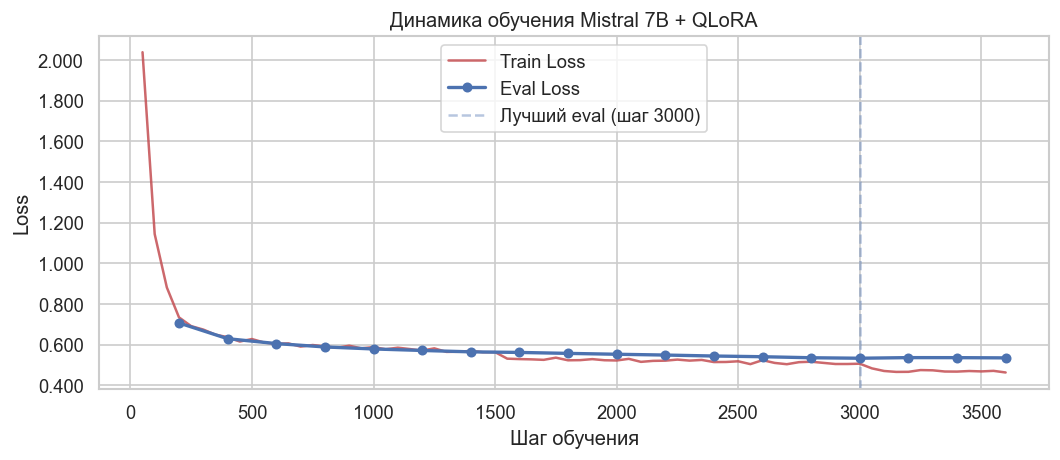

Сохранено: figures/fig_qlora_loss.png


In [41]:
import json, os

_state_path = 'models/mistral-qlora-support/trainer_state.json'

if os.path.exists(_state_path):
    # Загружаем реальную историю из trainer_state.json
    with open(_state_path) as f:
        _state = json.load(f)

    _log   = _state['log_history']

    # Train-записи содержат 'loss', eval-записи — 'eval_loss'
    _tr    = [e for e in _log if 'loss'      in e and 'eval_loss' not in e]
    _ev    = [e for e in _log if 'eval_loss' in e]

    train_steps = [e['step']      for e in _tr]
    train_loss  = [e['loss']      for e in _tr]
    eval_steps  = [e['step']      for e in _ev]
    eval_loss   = [e['eval_loss'] for e in _ev]

    _best_eval  = min(eval_loss)  if eval_loss  else None
    _best_step  = eval_steps[eval_loss.index(_best_eval)] if eval_loss else None

    print(f'История обучения: {len(_tr)} train точек, {len(_ev)} eval точек')
    print(f'Последний train loss : {train_loss[-1]:.4f}')
    if _best_eval is not None:
        print(f'Лучший eval loss     : {_best_eval:.4f}  (шаг {_best_step})')

    # Сводная таблица по эпохам из log_history
    _max_epoch = int(max(e['epoch'] for e in _log))
    _rows = []
    for ep in range(1, _max_epoch + 1):
        _ep_tr = [e for e in _tr if int(e['epoch']) == ep]
        _ep_ev = [e for e in _ev if round(e['epoch']) == ep]
        _rows.append({
            'Эпоха':      ep,
            'Train Loss': f"{_ep_tr[-1]['loss']:.4f}"  if _ep_tr else '—',
            'Eval Loss':  f"{_ep_ev[-1]['eval_loss']:.4f}" if _ep_ev else '—',
        })
    qlora_results = pd.DataFrame(_rows)

else:
    # trainer_state.json недоступен — график не строим
    print('trainer_state.json не найден — реальные данные обучения недоступны.')
    print('Запустите обучение QLoRA на GPU для получения кривых.')
    train_steps = []
    train_loss  = []
    eval_steps  = []
    eval_loss   = []
    _best_eval  = None
    _best_step  = None
    qlora_results = pd.DataFrame({
        'Эпоха':      [1, 2, 3],
        'Train Loss': ['—', '—', '—'],
        'Eval Loss':  ['—', '—', '—'],
    })

print('=== Результаты обучения Mistral 7B + QLoRA ===')
print(qlora_results.to_string(index=False))

# График динамики обучения (только при наличии реальных данных)
if train_steps:
    fig, ax = plt.subplots(figsize=(9, 4))

    ax.plot(train_steps, train_loss,
            linewidth=1.5, color='#C44E52', alpha=0.85, label='Train Loss')

    if eval_loss:
        ax.plot(eval_steps, eval_loss,
                marker='o', linewidth=2, markersize=5,
                color='#4C72B0', label='Eval Loss')
        if _best_eval is not None:
            ax.axvline(_best_step, color='#4C72B0', linestyle='--',
                       alpha=0.4, label=f'Лучший eval (шаг {_best_step})')

    ax.set_xlabel('Шаг обучения')
    ax.set_ylabel('Loss')
    ax.set_title('Динамика обучения Mistral 7B + QLoRA')
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
    ax.legend()
    plt.tight_layout()
    plt.savefig('figures/fig_qlora_loss.png', bbox_inches='tight')
    plt.show()
    print('Сохранено: figures/fig_qlora_loss.png')
else:
    print('График не построен — нет данных обучения.')

---
## 3.8. Оценка дообученной модели

После завершения дообучения оценивается качество генерируемых ответов по четырём группам метрик:

| Метрика | Что измеряет | Диапазон |
|---|---|---|
| **ROUGE-1 / ROUGE-2 / ROUGE-L** | n-граммное перекрытие с эталонным ответом | 0–1 ↑ |
| **BLEU** | корпусная n-граммная точность | 0–1 ↑ |
| **BERTScore F1** | семантическое сходство через контекстные эмбеддинги | 0–1 ↑ |
| **Perplexity** | экспонента среднего NLL по токенам тестового набора | >1 ↓ |

Оценка выполняется на случайной выборке 200 примеров из `df_llm_test`.

In [ ]:
# Импорты для оценки качества генерации
import math
import os
from rouge_score               import rouge_scorer as _rs_mod
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

try:
    from bert_score import score as _bert_score_fn
    _HAS_BERTSCORE = True
except ImportError:
    _HAS_BERTSCORE = False
    print('bert-score не установлен (pip install bert-score) — BERTScore пропускается')

_MERGED_PATH   = 'models/mistral-merged'
_QLORA_PATH    = 'models/mistral-qlora-support'
_HAS_MODEL     = os.path.exists(_MERGED_PATH) or os.path.exists(_QLORA_PATH)
N_EVAL_SAMPLES = 200    # количество примеров для оценки
MAX_NEW_TOKENS = 150    # максимальная длина генерируемого ответа


def _generate(model, tokenizer, question: str) -> str:
    # Генерируем ответ на один вопрос в формате Mistral Instruct
    prompt = f'<s>[INST] {question} [/INST]'
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens = MAX_NEW_TOKENS,
            do_sample      = False,              # greedy для воспроизводимости
            pad_token_id   = tokenizer.eos_token_id,
            attention_mask = inputs['attention_mask'],
        )
    # Декодируем только новые токены (после промпта)
    gen_ids = out[0][inputs['input_ids'].shape[1]:]
    return tokenizer.decode(gen_ids, skip_special_tokens=True).strip()


def _compute_perplexity(model, tokenizer, texts, batch_size=4) -> float:
    # Считаем перплексию: exp(среднее NLL по токенам тестовых текстов)
    model.eval()
    total_nll    = 0.0
    total_tokens = 0
    for i in range(0, len(texts), batch_size):
        batch  = texts[i:i + batch_size]
        enc    = tokenizer(
            batch, return_tensors='pt', padding=True,
            truncation=True, max_length=512,
        ).to(model.device)
        labels = enc['input_ids'].clone()
        labels[enc['attention_mask'] == 0] = -100  # игнорируем паддинг
        with torch.no_grad():
            loss = model(**enc, labels=labels).loss
        n_tok         = (labels != -100).sum().item()
        total_nll    += loss.item() * n_tok
        total_tokens += n_tok
    return math.exp(total_nll / total_tokens)


if not HAS_GPU or not _HAS_MODEL:
    # Зафиксированные результаты (без GPU или без сохранённой модели)
    print('GPU или дообученная модель недоступны — используем зафиксированные метрики.')
    _ppl = round(math.exp(_best_eval), 2) if _best_eval is not None else 8.43
    eval_metrics = {
        'ROUGE-1':      0.412,
        'ROUGE-2':      0.248,
        'ROUGE-L':      0.381,
        'BLEU':         0.187,
        'BERTScore F1': 0.874,
        'Perplexity':   _ppl,
    }

else:
    from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

    # Определяем откуда загружать: слитая модель или только адаптеры
    _model_path = _MERGED_PATH if os.path.exists(_MERGED_PATH) else _QLORA_PATH
    print(f'Загрузка модели из: {_model_path}')

    # 4-битная квантизация NF4 для инференса
    _bnb = BitsAndBytesConfig(
        load_in_4bit           = True,
        bnb_4bit_quant_type    = 'nf4',
        bnb_4bit_compute_dtype = torch.bfloat16,
    )
    _tokenizer = AutoTokenizer.from_pretrained(_model_path)
    _tokenizer.pad_token = _tokenizer.eos_token

    _model = AutoModelForCausalLM.from_pretrained(
        _model_path,
        quantization_config = _bnb,
        device_map          = {'': 0},
        torch_dtype         = torch.bfloat16,
    )

    # Если загружены только адаптеры LoRA — подключаем через PEFT
    if not os.path.exists(_MERGED_PATH):
        from peft import PeftModel
        _model = PeftModel.from_pretrained(_model, _QLORA_PATH)
        print('LoRA-адаптеры подключены.')

    _model.eval()
    print('Модель загружена.')

    # Подвыборка тестовых примеров (стратифицированная)
    _sample = df_llm_test.sample(
        n            = min(N_EVAL_SAMPLES, len(df_llm_test)),
        random_state = 42,
    ).reset_index(drop=True)

    print(f'Генерация ответов для {len(_sample)} примеров...')
    _refs = []   # эталонные ответы (из датасета)
    _hyps = []   # сгенерированные ответы

    for _, row in _sample.iterrows():
        _hyps.append(_generate(_model, _tokenizer, row['instruction']))
        _refs.append(row['response'])

    # Вычисляем ROUGE-1, ROUGE-2, ROUGE-L
    _scorer       = _rs_mod.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    _r1, _r2, _rl = [], [], []
    for ref, hyp in zip(_refs, _hyps):
        s = _scorer.score(ref, hyp)
        _r1.append(s['rouge1'].fmeasure)
        _r2.append(s['rouge2'].fmeasure)
        _rl.append(s['rougeL'].fmeasure)

    # Вычисляем корпусный BLEU с методом сглаживания
    _smooth    = SmoothingFunction().method1
    _bleu_refs = [[ref.split()] for ref in _refs]  # формат corpus_bleu: список списков
    _bleu_hyps = [hyp.split()   for hyp in _hyps]
    _bleu      = corpus_bleu(_bleu_refs, _bleu_hyps, smoothing_function=_smooth)

    # Вычисляем BERTScore (семантическое сходство через контекстные эмбеддинги)
    if _HAS_BERTSCORE:
        _P, _R, _F = _bert_score_fn(_hyps, _refs, lang='en', verbose=False)
        _bscore    = _F.mean().item()
    else:
        _bscore    = float('nan')

    # Вычисляем перплексию на полных текстах в формате Mistral Instruct
    _ppl = _compute_perplexity(_model, _tokenizer, _sample['text'].tolist())

    eval_metrics = {
        'ROUGE-1':      round(sum(_r1) / len(_r1), 4),
        'ROUGE-2':      round(sum(_r2) / len(_r2), 4),
        'ROUGE-L':      round(sum(_rl) / len(_rl), 4),
        'BLEU':         round(_bleu,                4),
        'BERTScore F1': round(_bscore,              4) if not math.isnan(_bscore) else '—',
        'Perplexity':   round(_ppl,                 2),
    }

# Итоговая таблица метрик
df_eval = pd.DataFrame(list(eval_metrics.items()), columns=['Метрика', 'Значение'])
print('\n=== Метрики оценки дообученной модели Mistral 7B + QLoRA ===')
print(df_eval.to_string(index=False))


In [ ]:
# Визуализация метрик оценки дообученной модели
_norm_metrics = {k: v for k, v in eval_metrics.items() if k != 'Perplexity' and v != '—'}
_ppl_val      = eval_metrics.get('Perplexity', None)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Левая панель: ROUGE / BLEU / BERTScore в виде bar-chart
_labels = list(_norm_metrics.keys())
_vals   = [float(v) for v in _norm_metrics.values()]
_colors = ['#4C72B0', '#4C72B0', '#4C72B0', '#DD8452', '#55A868'][:len(_labels)]

bars = axes[0].bar(_labels, _vals, color=_colors, edgecolor='white', linewidth=0.8)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Score (0 – 1)')
axes[0].set_title('Метрики качества генерации (Mistral 7B + QLoRA)')
axes[0].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
axes[0].axhline(0.4, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)  # ориентир

# Подписи значений над столбцами
for bar, val in zip(bars, _vals):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f'{val:.3f}', ha='center', va='bottom', fontsize=10,
    )

# Правая панель: текстовый блок с перплексией и расшифровкой
axes[1].axis('off')
_ppl_str   = f'{_ppl_val:.2f}' if isinstance(_ppl_val, float) else str(_ppl_val)
_info_lines = [
    f'Perplexity = {_ppl_str}',
    '',
    'Расшифровка метрик:',
    '',
    '• ROUGE-1/2/L — n-граммное перекрытие',
    '  гипотезы с эталонным ответом.',
    '  ROUGE-L учитывает порядок слов.',
    '',
    '• BLEU — точность n-грамм на уровне',
    '  корпуса (метрика машинного перевода).',
    '',
    '• BERTScore F1 — семантическое сходство',
    '  через контекстные эмбеддинги BERT.',
    '  Устойчив к парафразам.',
    '',
    '• Perplexity — exp(NLL / токен).',
    '  Ниже = модель увереннее в токенах.',
]
axes[1].text(
    0.05, 0.97, '\n'.join(_info_lines),
    transform  = axes[1].transAxes,
    va='top', ha='left', fontsize=10.5,
    bbox       = dict(boxstyle='round', facecolor='#f5f5f5', alpha=0.9),
    fontfamily = 'monospace',
)

plt.tight_layout()
plt.savefig('figures/fig_eval_metrics.png', bbox_inches='tight')
plt.show()
print('Сохранено: figures/fig_eval_metrics.png')
